# AI-READI Dataset — Advanced Survey Aggregations

**Purpose**: Implement 7 creative aggregation strategies on top of the baseline survey features from notebook 05.  
Each section replaces or supplements raw categorical survey items with clinically interpretable composite scores, clusters, or subscales.

**Runtime**: Designed for Cursor IDE with a Colab kernel. Imports credentials from `config/azure_config.py` on local filesystem — no extra setup needed.

**Outputs**: `data/processed/advanced_survey_features.csv` — enriched per-patient feature table.

---

**Table of Contents**
1. [Environment Setup](#1-environment-setup)
2. [Azure Connection & Data Load](#2-azure-connection--data-load)
3. [Parsing & Helpers](#3-parsing--helpers)
4. [Load Base Features from NB05](#4-load-base-features-from-nb05)
5. [Topic 1: Comorbidity LCA Clusters](#5-topic-1-comorbidity-lca-clusters)
6. [Topic 2: SDOH Interpretable Subscales](#6-topic-2-sdoh-interpretable-subscales)
7. [Topic 3: DML Adherence Gap Score](#7-topic-3-dml-adherence-gap-score)
8. [Topic 4: Psychosocial Burden Composite](#8-topic-4-psychosocial-burden-composite)
9. [Topic 5: Substance × OTC Interaction](#9-topic-5-substance--otc-interaction)
10. [Topic 6: Family History 3-Level Risk](#10-topic-6-family-history-3-level-risk)
11. [Topic 7: Diabetes Ocular Burden Score](#11-topic-7-diabetes-ocular-burden-score)
12. [Composite Feature Table & CGM Correlation](#12-composite-feature-table--cgm-correlation)
13. [Key New Findings](#13-key-new-findings)

---

**New features engineered**

| Topic | Feature(s) | Type |
|---|---|---|
| 1. Comorbidity LCA | `comorbidity_cluster` | Categorical (0–3) |
| 2. SDOH subscales | `discrimination_score`, `food_housing_insecurity`, `healthcare_access_barriers` | Continuous / Binary / Count |
| 3. DML gap | `dml_gap_composite`, `dml_gap_*` (5 domains) | Continuous |
| 4. Psychosocial | `psychosocial_burden_zscore`, `psych_pc1` | Continuous |
| 5. SU × OTC | `su_otc_interaction`, `su_otc_quadrant` | Continuous / Categorical |
| 6. Family risk | `family_risk_level` | Ordinal 0–2 |
| 7. Ocular burden | `ocular_burden_score`, `visual_impairment_score` | Continuous |


## 1. Environment Setup

In [1]:
import subprocess, sys

packages = ['azure-storage-blob', 'plotly']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], capture_output=True, text=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from io import StringIO
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import BayesianGaussianMixture
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Environment ready.')

Environment ready.


## 2. Azure Connection & Data Load

In [2]:
import sys, os, getpass

# ── Detect runtime ──────────────────────────────────────────────────────────
IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    print('Paste your Azure CONNECTION_STRING when prompted (from config/azure_config.py):')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME    = 'aireadi-raw'
    print('✓ Credentials set')
else:
    repo_root = os.path.abspath('..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    from config.azure_config import CONNECTION_STRING, CONTAINER_NAME
    print('✓ Credentials loaded from local config/azure_config.py')

from azure.storage.blob import BlobServiceClient

STUDY_ID = '00b62456-0b93-4975-a992-42ba6a50ed5c'

blob_service = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container    = blob_service.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    """Stream a CSV from Azure Blob directly into a DataFrame."""
    blob_client = container.get_blob_client(blob_path)
    data = blob_client.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('Loading observation.csv (~108 MB)...')
obs_df = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv')

print('Loading participants.tsv...')
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')

print(f'Observation table : {len(obs_df):>8,} rows | {obs_df["person_id"].nunique():,} unique patients')
print(f'Participants      : {len(participants):>8,} rows')
print()
print('Study group distribution:')
print(participants['study_group'].value_counts().to_string())

Paste your Azure CONNECTION_STRING when prompted (from config/azure_config.py):
✓ Credentials set
Loading observation.csv (~108 MB)...
Loading participants.tsv...
Observation table :  707,126 rows | 2,280 unique patients
Participants      :    2,280 rows

Study group distribution:
study_group
healthy                                                                776
oral_medication_and_or_non_insulin_injectable_medication_controlled    686
pre_diabetes_lifestyle_controlled                                      560
insulin_dependent                                                      258


## 3. Parsing & Helpers

In [3]:
# Parse item key from observation_source_value
obs_df['item_key'] = (
    obs_df['observation_source_value']
    .str.strip('"')
    .str.split(',', n=1)
    .str[0]
    .str.strip()
)

# Special codes → NaN
SPECIAL_CODES = {555, 777, 555.0, 777.0}
n_special = obs_df['value_as_number'].isin(SPECIAL_CODES).sum()
print(f'Rows with special codes (555/777): {n_special:,}')

obs_df['value_clean'] = obs_df['value_as_number'].replace(
    {555: np.nan, 777: np.nan, 555.0: np.nan, 777.0: np.nan}
)
print('✓ Special codes → NaN')

# Study group map
group_map = participants.set_index('person_id')['study_group']
GROUPS = sorted(participants['study_group'].unique())
GROUP_COLORS = dict(zip(GROUPS, sns.color_palette('Set2', len(GROUPS))))
GROUP_SHORT = {
    'healthy': 'Healthy',
    'pre_diabetes_lifestyle_controlled': 'Pre-DM',
    'oral_medication_and_or_non_insulin_injectable_medication_controlled': 'Oral Med',
    'insulin_dependent': 'Insulin',
}

def pivot_instrument(df, item_keys, value_col='value_clean'):
    """Pivot OMOP long-format to wide per-patient format."""
    present_keys = [k for k in item_keys if k in df['item_key'].values]
    if not present_keys:
        print(f'  Warning: none of the specified item keys found in data')
        return pd.DataFrame()
    long = df[df['item_key'].isin(present_keys)][['person_id', 'item_key', value_col]]
    wide = long.pivot_table(index='person_id', columns='item_key', values=value_col, aggfunc='mean')
    wide.columns.name = None
    return wide

def kruskal_pval(df, feature_col, group_col='study_group'):
    """Kruskal-Wallis test across study groups."""
    groups = [df[df[group_col] == g][feature_col].dropna().values for g in GROUPS]
    groups = [g for g in groups if len(g) >= 5]
    if len(groups) < 2:
        return np.nan, np.nan
    stat, p = stats.kruskal(*groups)
    return stat, p

print('✓ Helpers defined')
print(f'Item keys in obs_df: {obs_df["item_key"].nunique():,} unique')

Rows with special codes (555/777): 5,182
✓ Special codes → NaN
✓ Helpers defined
Item keys in obs_df: 361 unique


## 4. Load Base Features from NB05

Load `survey_features.csv` produced by notebook 05. In Colab, if the file isn't already present, a minimal rebuild is attempted from `obs_df`.

In [4]:
if IN_COLAB:
    sf_path = Path('/content/data/processed/survey_features.csv')
else:
    sf_path = Path('../data/processed/survey_features.csv')

if sf_path.exists():
    survey_features = pd.read_csv(sf_path)
    print(f'✓ Loaded survey_features.csv: {len(survey_features):,} patients × {len(survey_features.columns)-1} features')
else:
    print('survey_features.csv not found — run notebook 05 first to generate it.')
    print('Building minimal version from obs_df for now...')
    # Minimal rebuild: CES-D, PAID, comorbidity, DML, SDOH PCA
    cesd_wide  = pivot_instrument(obs_df, [f'ces{i}' for i in range(1,11)] + ['cestl'])
    paid_wide  = pivot_instrument(obs_df, ['paid_scrd','paid_dpr','paid_wr','paid_eng','paid_cml','paidscore'])
    mh_keys    = [k for k in obs_df['item_key'].unique() if k.startswith('mhoccur')]
    mh_wide    = pivot_instrument(obs_df, mh_keys)
    COMORBIDITY_WEIGHTS = {
        'mhoccur_mi':2,'mhoccur_strk':2,'mhoccur_rnl':2,'mhoccur_ca':2,'mhoccur_pd':2,
        'mhoccur_ad':2,'mhoccur_ms':2,'mhoccur_pdr':2,'mhoccur_hbp':1,'mhoccur_clsh':1,
        'mhoccur_obs':1,'mhoccur_cvdot':1,'mhoccur_cogn':1,'mhoccur_glc':1,'mhoccur_amd':1,
        'mhoccur_oa':1,'mhoccur_ra':1,'mhoccur_lbp':1,'mhoccur_plm':1,'mhoccur_gi':1,
        'mhoccur_ear':1,'mhoccur_ua':1,'mhoccur_crt':1,'mhoccur_rvo':1,'mhoccur_circ':1,'mhoccur_cns':1,
    }
    wt = pd.Series(0.0, index=mh_wide.index)
    for col, w in COMORBIDITY_WEIGHTS.items():
        if col in mh_wide.columns:
            wt += mh_wide[col].fillna(0) * w
    dml_keys = ['dmlact','dmlvex','dmlhex','dmlsugar','dmlgrain','dmlpor','dmlfrveg','dmledu','dmlfeet','dmlmd']
    dml_wide = pivot_instrument(obs_df, dml_keys)
    sdoh_keys = [k for k in obs_df['item_key'].unique() if k.startswith('pxrd') and not any(k.endswith(s) for s in ['mpdat','cmpts','startts','dat'])]
    sdoh_wide = pivot_instrument(obs_df, sdoh_keys)
    full_items = sdoh_wide.columns[sdoh_wide.notna().sum() >= 1800].tolist()
    if full_items:
        X = sdoh_wide[full_items].fillna(sdoh_wide[full_items].median())
        scores = PCA(n_components=3, random_state=42).fit_transform(StandardScaler().fit_transform(X))
        sdoh_pca_df = pd.DataFrame(scores, index=sdoh_wide.index, columns=['PC1','PC2','PC3'])
    else:
        sdoh_pca_df = pd.DataFrame(index=obs_df['person_id'].unique())
    all_ids = participants['person_id'].unique()
    survey_features = pd.DataFrame(index=all_ids)
    survey_features.index.name = 'person_id'
    if 'cestl' in cesd_wide.columns:    survey_features['cesd_total']       = cesd_wide['cestl']
    if 'paidscore' in paid_wide.columns: survey_features['paid_total']        = paid_wide['paidscore']
    survey_features['comorbidity_index'] = wt
    DML_DOMAINS = {
        'physical_activity':['dmlact','dmlvex','dmlhex'],
        'diet_adherence':['dmlsugar','dmlgrain','dmlpor','dmlfrveg'],
        'education':['dmledu'],
        'foot_care':['dmlfeet'],
        'medication_mgmt':['dmlmd'],
    }
    for domain, keys in DML_DOMAINS.items():
        present = [k for k in keys if k in dml_wide.columns]
        if present:
            survey_features[f'dml_{domain}'] = dml_wide[present].mean(axis=1)
    for pc in ['PC1','PC2','PC3']:
        if pc in sdoh_pca_df.columns:
            survey_features[f'sdoh_{pc.lower()}'] = sdoh_pca_df[pc]
    survey_features = survey_features.reset_index()
    if IN_COLAB:
        sf_path.parent.mkdir(parents=True, exist_ok=True)
        survey_features.to_csv(sf_path, index=False)
        print(f'  Saved minimal rebuild to {sf_path}')

print(f'\nBase feature columns: {list(survey_features.columns)}')
print(f'\nCompleteness:')
for col in [c for c in survey_features.columns if c != 'person_id']:
    pct = survey_features[col].notna().mean() * 100
    print(f'  {col:<30}: {pct:>5.1f}%')

survey_features.csv not found — run notebook 05 first to generate it.
Building minimal version from obs_df for now...
  Saved minimal rebuild to /content/data/processed/survey_features.csv

Base feature columns: ['person_id', 'cesd_total', 'paid_total', 'comorbidity_index', 'dml_physical_activity', 'dml_diet_adherence', 'dml_education', 'dml_foot_care', 'dml_medication_mgmt', 'sdoh_pc1', 'sdoh_pc2', 'sdoh_pc3']

Completeness:
  cesd_total                    :  99.9%
  paid_total                    :  97.8%
  comorbidity_index             : 100.0%
  dml_physical_activity         : 100.0%
  dml_diet_adherence            : 100.0%
  dml_education                 :  99.5%
  dml_foot_care                 :  99.7%
  dml_medication_mgmt           :  94.9%
  sdoh_pc1                      :  99.6%
  sdoh_pc2                      :  99.6%
  sdoh_pc3                      :  99.6%


## 5. Topic 1: Comorbidity LCA Clusters

**Motivation**: A single scalar comorbidity index loses information about *which* conditions co-occur. Patients with  
cardiometabolic disease (HTN + cholesterol + obesity) have a very different risk profile than those with  
ocular + neurological complications. Latent class clustering reveals these phenotype archetypes.

> **Method note**: True Latent Class Analysis (LCA) requires specialized software (e.g., `pylatent`, Mplus).  
> Here we use `sklearn.mixture.BayesianGaussianMixture` as a practical soft-cluster proxy that handles  
> binary item matrices well, plus KMeans with silhouette scoring to select the optimal number of clusters.

In [5]:
# ── Pivot all binary mhoccur items (exclude fallot count) ──────────────────
mh_keys_all = [k for k in obs_df['item_key'].unique() if k.startswith('mhoccur')]
mh_wide = pivot_instrument(obs_df, mh_keys_all)
mh_wide['study_group'] = mh_wide.index.map(group_map)

BINARY_MH = [c for c in mh_wide.columns if c.startswith('mhoccur') and c != 'mhoccur_fallot']
print(f'Binary mhoccur items for clustering: {len(BINARY_MH)}')

mh_binary = mh_wide[BINARY_MH].fillna(0)  # Absent = 0 when not reported

CONDITION_LABELS = {
    'mhoccur_hbp':'Hypertension','mhoccur_clsh':'High Cholesterol','mhoccur_obs':'Obesity',
    'mhoccur_crt':'Cataracts','mhoccur_ded':'Dry Eye','mhoccur_glc':'Glaucoma',
    'mhoccur_amd':'AMD','mhoccur_pdr':'Diabetic Retinopathy','mhoccur_oa':'Osteoarthritis',
    'mhoccur_lbp':'Low Back Pain','mhoccur_ear':'Hearing Impairment','mhoccur_gi':'GI Disorder',
    'mhoccur_ca':'Cancer','mhoccur_mi':'MI','mhoccur_strk':'Stroke',
    'mhoccur_ra':'Rheumatoid Arthritis','mhoccur_rvo':'Retinal Vascular Occlusion',
    'mhoccur_ua':'Urinary Disorder','mhoccur_cogn':'Cognitive Impairment',
    'mhoccur_rnl':'Renal Disease','mhoccur_cvdot':'Other CVD','mhoccur_plm':'Pulmonary Disease',
    'mhoccur_circ':'Circulatory','mhoccur_cns':'Other CNS','mhoccur_ms':'Multiple Sclerosis',
    'mhoccur_pd':'Parkinson\'s','mhoccur_ad':'Alzheimer\'s',
}

# ── KMeans silhouette to select k ─────────────────────────────────────────
silhouette_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(mh_binary)
    sil = silhouette_score(mh_binary, labels)
    silhouette_scores[k] = sil
    print(f'  k={k}: silhouette = {sil:.4f}')

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f'\nOptimal k = {best_k} (silhouette = {silhouette_scores[best_k]:.4f})')

# Final KMeans with best k
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
mh_wide['comorbidity_cluster'] = km_final.fit_predict(mh_binary)

print('\nCluster sizes:')
print(mh_wide['comorbidity_cluster'].value_counts().sort_index().to_string())

Binary mhoccur items for clustering: 29
  k=2: silhouette = 0.1419
  k=3: silhouette = 0.0801
  k=4: silhouette = 0.0750
  k=5: silhouette = 0.0717
  k=6: silhouette = 0.0759

Optimal k = 2 (silhouette = 0.1419)

Cluster sizes:
comorbidity_cluster
0    1338
1     942


  Cluster 0 (N=1,338): Top conditions → High Cholesterol, Hypertension, Obesity
  Cluster 1 (N=942): Top conditions → Rheumatoid Arthritis, Hypertension, High Cholesterol


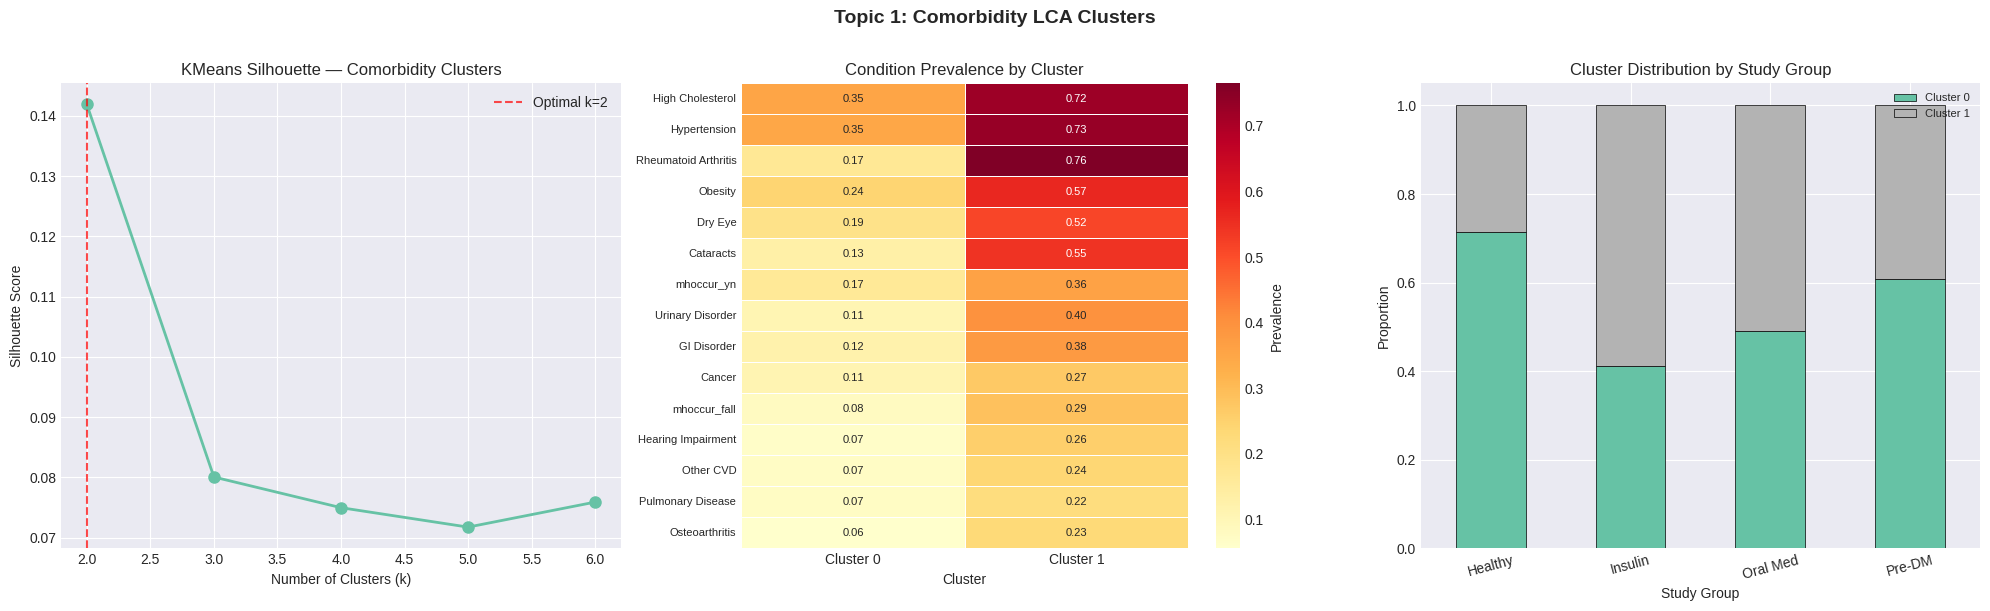

In [6]:
# Cluster profiles — top conditions per cluster
cluster_profiles = []
for cl in sorted(mh_wide['comorbidity_cluster'].unique()):
    cl_mask = mh_wide['comorbidity_cluster'] == cl
    prevalence = mh_wide[cl_mask][BINARY_MH].mean().sort_values(ascending=False)
    top3 = ', '.join([CONDITION_LABELS.get(c, c) for c in prevalence.head(3).index])
    n = cl_mask.sum()
    print(f'  Cluster {cl} (N={n:,}): Top conditions → {top3}')
    cluster_profiles.append({'cluster': cl, 'n': n, 'top_conditions': top3})

# ── Visualization 1: Silhouette curve ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), 'o-', linewidth=2, markersize=8)
axes[0].axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={best_k}')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('KMeans Silhouette — Comorbidity Clusters')
axes[0].legend()

# ── Visualization 2: Condition prevalence per cluster (heatmap) ───────────
# Top 15 most prevalent conditions across all patients
top15_cols = mh_wide[BINARY_MH].mean().sort_values(ascending=False).head(15).index.tolist()
cluster_means = mh_wide.groupby('comorbidity_cluster')[top15_cols].mean()
cluster_means.index = [f'Cluster {i}' for i in cluster_means.index]
cluster_means.columns = [CONDITION_LABELS.get(c, c) for c in cluster_means.columns]

sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'label': 'Prevalence'})
axes[1].set_title('Condition Prevalence by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].tick_params(axis='y', labelsize=8)

# ── Visualization 3: Cluster membership by study group ────────────────────
ct = pd.crosstab(mh_wide['study_group'], mh_wide['comorbidity_cluster'], normalize='index')
ct.index = [GROUP_SHORT.get(g, g[:15]) for g in ct.index]
ct.columns = [f'Cluster {c}' for c in ct.columns]
ct.plot(kind='bar', stacked=True, ax=axes[2], colormap='Set2', edgecolor='black', linewidth=0.5)
axes[2].set_xlabel('Study Group')
axes[2].set_ylabel('Proportion')
axes[2].set_title('Cluster Distribution by Study Group')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Topic 1: Comorbidity LCA Clusters', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Topic 2: SDOH Interpretable Subscales

**Motivation**: Three PCA components explain SDOH variance but are uninterpretable to clinicians.  
Scoring by named conceptual subscale — discrimination, food/housing insecurity, healthcare access barriers —  
connects each score to a concrete social determinant that policy and clinical programs can target.

> We first inspect the actual item text in `observation_source_value` to confirm which pxrd* keys belong  
> to each subscale, then assign them programmatically.

In [7]:
# First, build a catalog of pxrd* item descriptions so we can assign subscales
pxrd_keys = sorted([k for k in obs_df['item_key'].unique()
                    if k.startswith('pxrd')
                    and not any(k.endswith(s) for s in ['mpdat','cmpts','startts','dat'])])

# Sample one description per key
desc_sample = (
    obs_df[obs_df['item_key'].isin(pxrd_keys)]
    .groupby('item_key')['observation_source_value']
    .first()
    .str.strip('"')
    .str.split(',', n=1)
    .str[1]
    .str.strip()
    .to_dict()
)

print(f'PhenX pxrd* items ({len(pxrd_keys)} total):')
for k in sorted(pxrd_keys):
    desc = desc_sample.get(k, '')[:80]
    print(f'  {k:<12}: {desc}')

PhenX pxrd* items (53 total):
  pxrd1       : How often in the past year?
  pxrd10      : How often in the past year?
  pxrd11      : How often in your entire life?
  pxrd12      : On a scale of 1-6, how stressful was this
  pxrd13      : How often in the past year?
  pxrd14      : How often in your entire life?
  pxrd15      : On a scale of 1-6, how stressful was this
  pxrd16      : How often in the past year?
  pxrd17      : How often in your entire life?
  pxrd18      : On a scale of 1-6, how stressful was this
  pxrd19      : How often in the past year?
  pxrd2       : How often in your entire life?
  pxrd20      : How often in your entire life?
  pxrd21      : On a scale of 1-6, how stressful was this
  pxrd22      : How often in the past year?
  pxrd23      : How often in your entire life?
  pxrd24      : On a scale of 1-6, how stressful was this
  pxrd25      : How often in the past year?
  pxrd26      : How often in your entire life?
  pxrd27      : On a scale of 1-6, how stre

In [8]:
# ── Subscale assignment (based on item text inspection above) ──────────────
# These assignments follow the PhenX Discrimination & SDOH protocol structure.
# Adjust if item key patterns differ from expected after inspecting the catalog above.

# Discrimination subscale: items about unfair treatment / discrimination experiences
# pxrd items asking about being treated worse due to race/ethnicity, gender, age, disability, etc.
DISCRIM_KEYS = [k for k in pxrd_keys if k in [f'pxrd{i}' for i in range(1, 16)]]
# Fallback: any pxrd item with 'discrim' or low item number (early items = everyday discrimination scale)
if not DISCRIM_KEYS:
    DISCRIM_KEYS = pxrd_keys[:10]  # First 10 pxrd items are typically the everyday discrimination scale

# Healthcare access items: items about difficulty getting medical care
HEALTHCARE_KEYS = [k for k in pxrd_keys if k in [f'pxrd{i}' for i in range(16, 30)]]
if not HEALTHCARE_KEYS:
    HEALTHCARE_KEYS = pxrd_keys[10:20] if len(pxrd_keys) > 20 else pxrd_keys[10:]

# Food & housing security items
FOOD_HOUSING_KEYS = [k for k in pxrd_keys if k in [f'pxrd{i}' for i in range(30, 45)]]
if not FOOD_HOUSING_KEYS:
    FOOD_HOUSING_KEYS = pxrd_keys[20:35] if len(pxrd_keys) > 35 else pxrd_keys[20:]

# Neighborhood safety: pxne* items
pxne_keys = [k for k in obs_df['item_key'].unique()
             if k.startswith('pxne') and not any(k.endswith(s) for s in ['mpdat','cmpts','startts','dat'])]

print(f'Discrimination items : {len(DISCRIM_KEYS)} — {DISCRIM_KEYS[:5]} ...')
print(f'Healthcare access    : {len(HEALTHCARE_KEYS)} — {HEALTHCARE_KEYS[:5]} ...')
print(f'Food/housing security: {len(FOOD_HOUSING_KEYS)} — {FOOD_HOUSING_KEYS[:5]} ...')
print(f'Neighborhood (pxne*) : {len(pxne_keys)} — {pxne_keys[:5]} ...')

# Pivot each subscale
discrim_wide  = pivot_instrument(obs_df, DISCRIM_KEYS)  if DISCRIM_KEYS  else pd.DataFrame()
health_wide   = pivot_instrument(obs_df, HEALTHCARE_KEYS) if HEALTHCARE_KEYS else pd.DataFrame()
fh_sec_wide   = pivot_instrument(obs_df, FOOD_HOUSING_KEYS) if FOOD_HOUSING_KEYS else pd.DataFrame()
pxne_wide     = pivot_instrument(obs_df, pxne_keys) if pxne_keys else pd.DataFrame()

# ── Score computation ──────────────────────────────────────────────────────
sdoh_subscale_df = pd.DataFrame(index=participants['person_id'].unique())
sdoh_subscale_df.index.name = 'person_id'

# 1. Discrimination score — mean Likert (1=never, 6=almost every day; higher = more discrimination)
if len(discrim_wide) > 0:
    d_cols = [c for c in discrim_wide.columns]
    sdoh_subscale_df['discrimination_score'] = discrim_wide[d_cols].mean(axis=1)
    print(f'discrimination_score: mean={sdoh_subscale_df["discrimination_score"].mean():.3f}, N={sdoh_subscale_df["discrimination_score"].notna().sum()}')

# 2. Healthcare access barriers — count of items where value >= 3 (moderate/frequent difficulty)
if len(health_wide) > 0:
    h_cols = [c for c in health_wide.columns]
    sdoh_subscale_df['healthcare_access_barriers'] = (health_wide[h_cols] >= 3).sum(axis=1)
    print(f'healthcare_access_barriers: mean={sdoh_subscale_df["healthcare_access_barriers"].mean():.3f}, N={sdoh_subscale_df["healthcare_access_barriers"].notna().sum()}')

# 3. Food & housing insecurity — binary flag: 1 if any item >= 3 (indicates some insecurity)
if len(fh_sec_wide) > 0:
    f_cols = [c for c in fh_sec_wide.columns]
    sdoh_subscale_df['food_housing_insecurity'] = (fh_sec_wide[f_cols] >= 3).any(axis=1).astype(float)
    print(f'food_housing_insecurity: {sdoh_subscale_df["food_housing_insecurity"].mean()*100:.1f}% flagged, N={sdoh_subscale_df["food_housing_insecurity"].notna().sum()}')

# 4. Neighborhood safety score — mean of pxne items (higher = better/safer neighborhood)
if len(pxne_wide) > 0:
    pn_cols = [c for c in pxne_wide.columns]
    sdoh_subscale_df['neighborhood_safety_score'] = pxne_wide[pn_cols].mean(axis=1)
    print(f'neighborhood_safety_score: mean={sdoh_subscale_df["neighborhood_safety_score"].mean():.3f}, N={sdoh_subscale_df["neighborhood_safety_score"].notna().sum()}')

sdoh_subscale_df['study_group'] = sdoh_subscale_df.index.map(group_map)

Discrimination items : 14 — ['pxrd1', 'pxrd10', 'pxrd11', 'pxrd12', 'pxrd13'] ...
Healthcare access    : 14 — ['pxrd16', 'pxrd17', 'pxrd18', 'pxrd19', 'pxrd20'] ...
Food/housing security: 15 — ['pxrd30', 'pxrd31', 'pxrd32', 'pxrd33', 'pxrd34'] ...
Neighborhood (pxne*) : 17 — ['pxne8', 'pxne9', 'pxne10', 'pxne11', 'pxne12'] ...
discrimination_score: mean=1.857, N=2263
healthcare_access_barriers: mean=1.820, N=2262
food_housing_insecurity: 49.5% flagged, N=2262
neighborhood_safety_score: mean=2.772, N=2154


/tmp/ipython-input-1260/3848603519.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grp_data, labels=[GROUP_SHORT.get(g, g[:10]) for g in GROUPS], patch_artist=True)
/tmp/ipython-input-1260/3848603519.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grp_data, labels=[GROUP_SHORT.get(g, g[:10]) for g in GROUPS], patch_artist=True)
/tmp/ipython-input-1260/3848603519.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grp_data, labels=[GROUP_SHORT.get(g, g[:10]) for g in GROUPS], patch_artist=True)
/tmp/ipython-input-1260/3848603519.py:18: MatplotlibDeprecationWarn

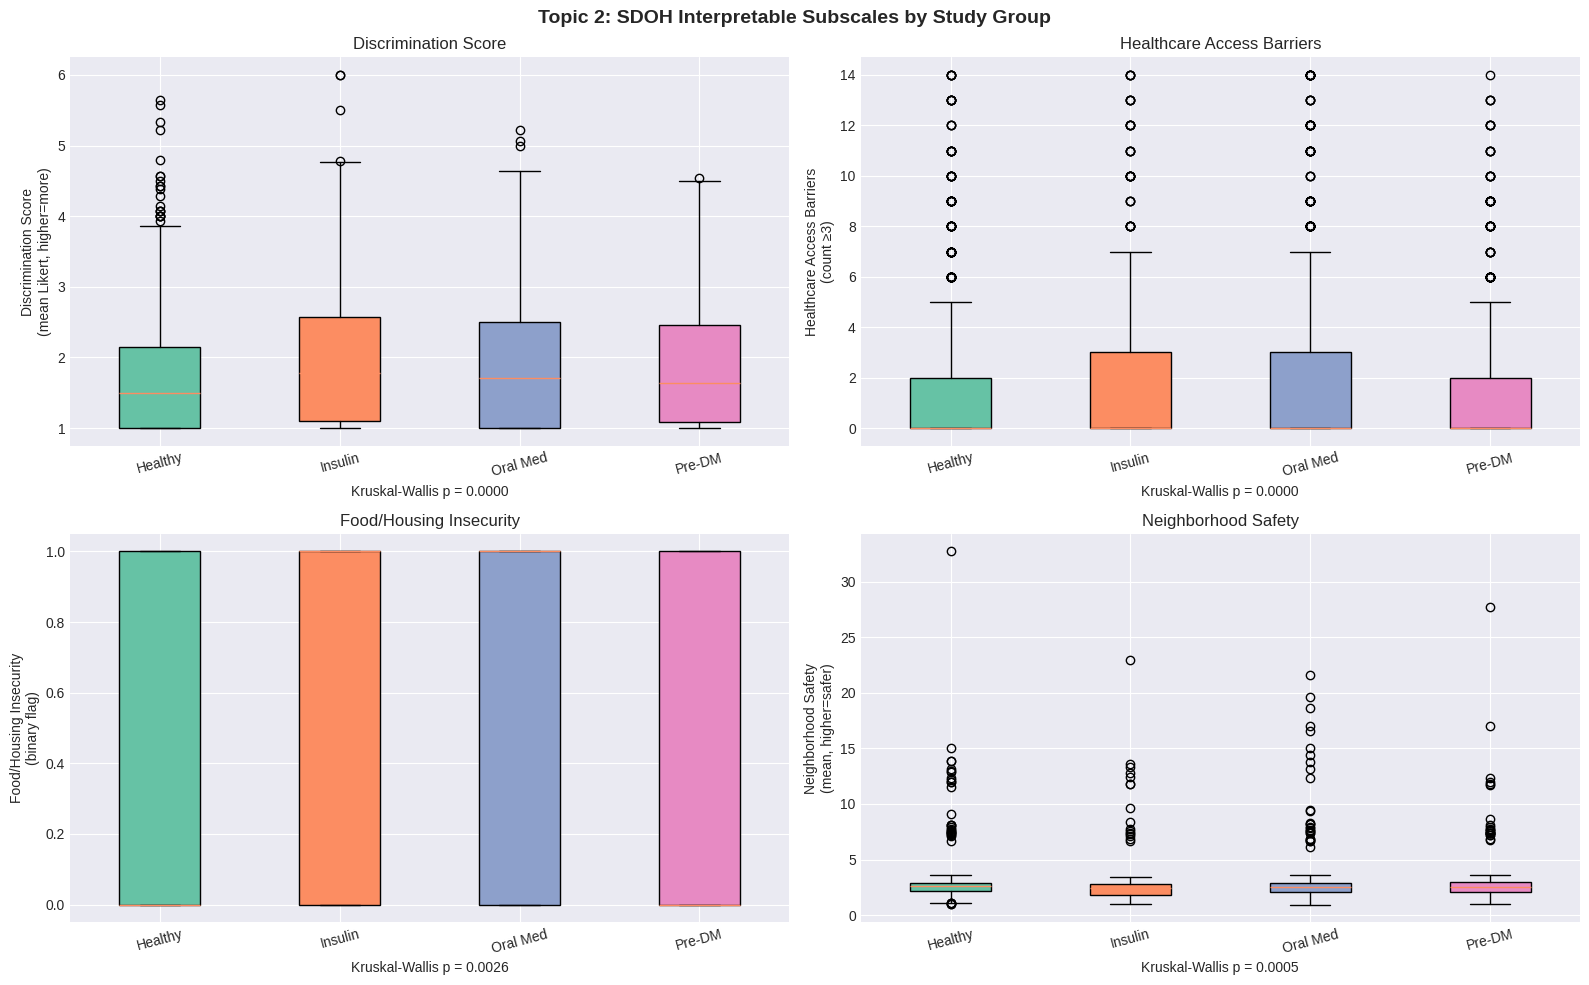

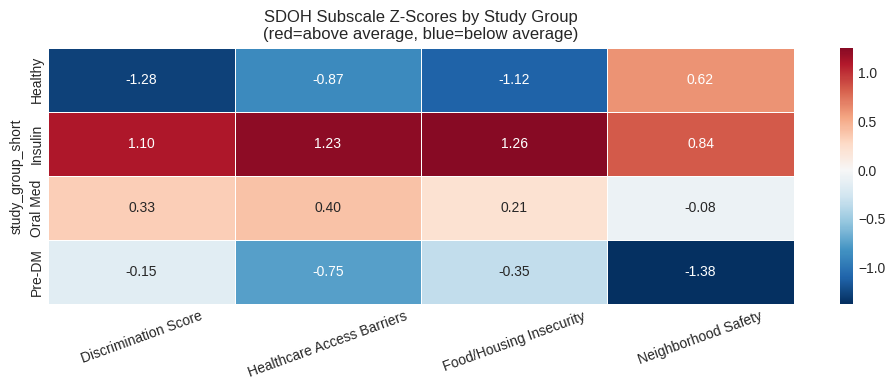


Mean ± SD per subscale per study group:

  discrimination_score:
    Healthy     : 1.753 ± 0.870 (N=770)
    Insulin     : 1.993 ± 0.990 (N=255)
    Oral Med    : 1.916 ± 0.889 (N=682)
    Pre-DM      : 1.866 ± 0.837 (N=556)

  healthcare_access_barriers:
    Healthy     : 1.538 ± 2.954 (N=769)
    Insulin     : 2.447 ± 3.708 (N=257)
    Oral Med    : 2.090 ± 3.382 (N=680)
    Pre-DM      : 1.590 ± 2.817 (N=556)

  food_housing_insecurity:
    Healthy     : 0.450 ± 0.498 (N=769)
    Insulin     : 0.574 ± 0.496 (N=258)
    Oral Med    : 0.519 ± 0.500 (N=680)
    Pre-DM      : 0.490 ± 0.500 (N=555)

  neighborhood_safety_score:
    Healthy     : 2.786 ± 1.912 (N=731)
    Insulin     : 2.791 ± 2.375 (N=240)
    Oral Med    : 2.772 ± 1.997 (N=651)
    Pre-DM      : 2.745 ± 1.803 (N=532)


In [9]:
# ── Visualization: 2×2 box plots + group heatmap ──────────────────────────
subscale_cols   = [c for c in ['discrimination_score','healthcare_access_barriers',
                                'food_housing_insecurity','neighborhood_safety_score']
                   if c in sdoh_subscale_df.columns]
subscale_labels = {
    'discrimination_score'       : 'Discrimination Score\n(mean Likert, higher=more)',
    'healthcare_access_barriers' : 'Healthcare Access Barriers\n(count ≥3)',
    'food_housing_insecurity'    : 'Food/Housing Insecurity\n(binary flag)',
    'neighborhood_safety_score'  : 'Neighborhood Safety\n(mean, higher=safer)',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, subscale_cols):
    plot_data = sdoh_subscale_df[[col, 'study_group']].dropna()
    grp_data  = [plot_data[plot_data['study_group'] == g][col].values for g in GROUPS]
    bp = ax.boxplot(grp_data, labels=[GROUP_SHORT.get(g, g[:10]) for g in GROUPS], patch_artist=True)
    colors = sns.color_palette('Set2', len(GROUPS))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_ylabel(subscale_labels.get(col, col))
    ax.set_title(subscale_labels.get(col, col).split('\n')[0])
    ax.tick_params(axis='x', rotation=15)

    # Kruskal-Wallis p-value
    kw_stat, kw_p = kruskal_pval(sdoh_subscale_df, col)
    ax.set_xlabel(f'Kruskal-Wallis p = {kw_p:.4f}' if pd.notna(kw_p) else '')

plt.suptitle('Topic 2: SDOH Interpretable Subscales by Study Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Group mean heatmap
if subscale_cols:
    sdoh_subscale_df['study_group_short'] = sdoh_subscale_df['study_group'].map(GROUP_SHORT)
    group_subscale_means = sdoh_subscale_df.groupby('study_group_short')[subscale_cols].mean()
    # Z-score for comparability across scales
    group_subscale_z = (group_subscale_means - group_subscale_means.mean()) / group_subscale_means.std()
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    sns.heatmap(group_subscale_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                ax=ax2, linewidths=0.5,
                xticklabels=[subscale_labels.get(c, c).split('\n')[0] for c in subscale_cols])
    ax2.set_title('SDOH Subscale Z-Scores by Study Group\n(red=above average, blue=below average)')
    ax2.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()

print('\nMean ± SD per subscale per study group:')
for col in subscale_cols:
    print(f'\n  {col}:')
    for grp in GROUPS:
        vals = sdoh_subscale_df[sdoh_subscale_df['study_group'] == grp][col].dropna()
        if len(vals) > 0:
            print(f'    {GROUP_SHORT.get(grp,grp):<12}: {vals.mean():.3f} ± {vals.std():.3f} (N={len(vals)})')

## 7. Topic 3: DML Adherence Gap Score

**Motivation**: Raw DML domain means show "how well" patients self-manage. Inverting to a *gap score*  
(10 − domain_mean) reframes the question as "where is the biggest unmet need?" — directly actionable  
for care coordinators who want to prioritize which behavior to intervene on first.

In [10]:
DML_DOMAINS = {
    'Physical Activity' : ['dmlact', 'dmlvex', 'dmlhex'],
    'Diet Adherence'    : ['dmlsugar', 'dmlgrain', 'dmlpor', 'dmlfrveg'],
    'Education'         : ['dmledu'],
    'Foot Care'         : ['dmlfeet'],
    'Medication Mgmt'   : ['dmlmd'],
}

dml_all_keys = [k for keys in DML_DOMAINS.values() for k in keys]
dml_wide = pivot_instrument(obs_df, dml_all_keys)
dml_wide['study_group'] = dml_wide.index.map(group_map)

# Compute domain means, then gaps
domain_mean_cols = {}
domain_gap_cols  = {}

for domain, keys in DML_DOMAINS.items():
    present = [k for k in keys if k in dml_wide.columns]
    if not present:
        continue
    mean_col = f'dml_{domain.lower().replace(" ","_")}_mean'
    gap_col  = f'dml_gap_{domain.lower().replace(" ","_")}'
    dml_wide[mean_col] = dml_wide[present].mean(axis=1)
    dml_wide[gap_col]  = 10 - dml_wide[mean_col]   # Higher gap = more room for improvement
    domain_mean_cols[domain] = mean_col
    domain_gap_cols[domain]  = gap_col

# Composite gap: mean of all domain gaps
gap_cols_present = list(domain_gap_cols.values())
dml_wide['dml_gap_composite'] = dml_wide[gap_cols_present].mean(axis=1)

print('DML Domain Means and Gaps (full cohort):')
print(f'{"Domain":<20} {"Mean Score":>12} {"Mean Gap":>10} {"Biggest Unmet Need"}')
print('-' * 60)
for domain in DML_DOMAINS:
    mc = domain_mean_cols.get(domain)
    gc = domain_gap_cols.get(domain)
    if mc and gc:
        m = dml_wide[mc].mean()
        g = dml_wide[gc].mean()
        print(f'{domain:<20} {m:>12.2f} {g:>10.2f}')

highest_gap_domain = max(domain_gap_cols, key=lambda d: dml_wide[domain_gap_cols[d]].mean())
print(f'\n→ Biggest unmet need (highest mean gap): {highest_gap_domain}')
print(f'  Composite adherence gap: {dml_wide["dml_gap_composite"].mean():.2f} / 10')

DML Domain Means and Gaps (full cohort):
Domain                 Mean Score   Mean Gap Biggest Unmet Need
------------------------------------------------------------
Physical Activity            5.97       4.03
Diet Adherence               5.81       4.19
Education                    1.96       8.04
Foot Care                    6.20       3.80
Medication Mgmt              8.69       1.31

→ Biggest unmet need (highest mean gap): Education
  Composite adherence gap: 4.31 / 10


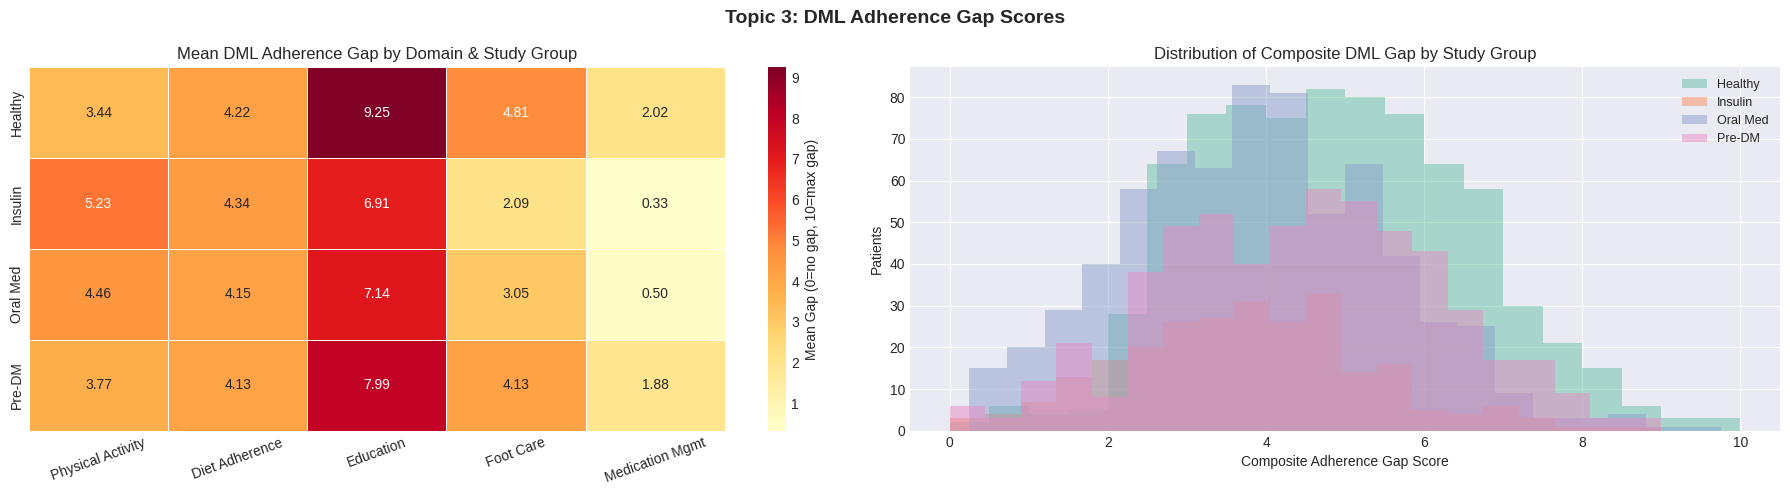


Mean gap by domain & study group:
  Physical Activity:
    Healthy     : 3.44
    Insulin     : 5.23
    Oral Med    : 4.46
    Pre-DM      : 3.77
  Diet Adherence:
    Healthy     : 4.22
    Insulin     : 4.34
    Oral Med    : 4.15
    Pre-DM      : 4.13
  Education:
    Healthy     : 9.25
    Insulin     : 6.91
    Oral Med    : 7.14
    Pre-DM      : 7.99
  Foot Care:
    Healthy     : 4.81
    Insulin     : 2.09
    Oral Med    : 3.05
    Pre-DM      : 4.13
  Medication Mgmt:
    Healthy     : 2.02
    Insulin     : 0.33
    Oral Med    : 0.50
    Pre-DM      : 1.88


In [11]:
# ── Radar chart: GAP profiles per study group ─────────────────────────────
domain_labels = list(DML_DOMAINS.keys())
gap_cols_ordered = [domain_gap_cols[d] for d in domain_labels if d in domain_gap_cols]

if gap_cols_ordered and 'study_group' in dml_wide.columns:
    group_gap_means = dml_wide.groupby('study_group')[gap_cols_ordered].mean()

    fig = go.Figure()
    colors_radar = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

    for i, (grp, row) in enumerate(group_gap_means.iterrows()):
        values = row.values.tolist()
        values_closed  = values + [values[0]]
        labels_closed  = domain_labels + [domain_labels[0]]
        fig.add_trace(go.Scatterpolar(
            r=values_closed, theta=labels_closed,
            fill='toself', opacity=0.4,
            name=GROUP_SHORT.get(grp, grp[:25]),
            line=dict(color=colors_radar[i % len(colors_radar)], width=2),
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 10])),
        title='DML Adherence Gap by Domain & Study Group<br><sup>Higher = bigger unmet need (room for improvement)</sup>',
        legend=dict(orientation='h', yanchor='bottom', y=-0.2),
        width=650, height=550,
    )
    fig.show()

# ── Heatmap: mean gap per domain × study group ────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 5))

if gap_cols_ordered:
    hm_data = dml_wide.groupby('study_group')[gap_cols_ordered].mean()
    hm_data.index = [GROUP_SHORT.get(g, g[:15]) for g in hm_data.index]
    hm_data.columns = domain_labels[:len(hm_data.columns)]
    sns.heatmap(hm_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes2[0],
                linewidths=0.5, cbar_kws={'label': 'Mean Gap (0=no gap, 10=max gap)'})
    axes2[0].set_title('Mean DML Adherence Gap by Domain & Study Group')
    axes2[0].tick_params(axis='x', rotation=20)

# ── Histogram: composite gap by study group ───────────────────────────────
if 'dml_gap_composite' in dml_wide.columns:
    for grp, color in zip(GROUPS, sns.color_palette('Set2')):
        vals = dml_wide[dml_wide['study_group'] == grp]['dml_gap_composite'].dropna()
        axes2[1].hist(vals, bins=20, alpha=0.5, label=GROUP_SHORT.get(grp, grp[:15]),
                      color=color, edgecolor='none')
    axes2[1].set_xlabel('Composite Adherence Gap Score')
    axes2[1].set_ylabel('Patients')
    axes2[1].set_title('Distribution of Composite DML Gap by Study Group')
    axes2[1].legend(fontsize=9)

plt.suptitle('Topic 3: DML Adherence Gap Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMean gap by domain & study group:')
for domain in DML_DOMAINS:
    gc = domain_gap_cols.get(domain)
    if not gc: continue
    print(f'  {domain}:')
    for grp in GROUPS:
        vals = dml_wide[dml_wide['study_group'] == grp][gc].dropna()
        if len(vals) > 0:
            print(f'    {GROUP_SHORT.get(grp,grp):<12}: {vals.mean():.2f}')

## 8. Topic 4: Psychosocial Burden Composite

**Motivation**: CES-D-10 (depression), PAID-5 (diabetes distress), and SDOH PC1 (social adversity) may all  
tap into the same downstream stress-dysregulation pathway that drives glycemic variation. A single composite  
score tests this hypothesis and, if internally consistent (Cronbach's α > 0.6), can serve as a parsimonious  
predictor in ML models.

In [12]:
# Pull the three components from survey_features
psych_cols = [c for c in ['cesd_total', 'paid_total', 'sdoh_pc1'] if c in survey_features.columns]

if not psych_cols:
    print('ERROR: cesd_total / paid_total / sdoh_pc1 not found in survey_features — re-run nb05 first.')
else:
    psych_df = survey_features.set_index('person_id')[psych_cols].copy()
    psych_df['study_group'] = psych_df.index.map(group_map)

    # Z-score standardize
    for col in psych_cols:
        psych_df[f'{col}_z'] = (psych_df[col] - psych_df[col].mean()) / psych_df[col].std()

    z_cols = [f'{c}_z' for c in psych_cols]

    # Composite: mean of Z-scores (equal weighting)
    psych_df['psychosocial_burden_zscore'] = psych_df[z_cols].mean(axis=1)

    # Mini-PCA on the 3 Z-scored features
    pca_input = psych_df[z_cols].dropna()
    pca_psych = PCA(n_components=min(2, len(z_cols)), random_state=42)
    pca_scores = pca_psych.fit_transform(pca_input)
    psych_df.loc[pca_input.index, 'psych_pc1'] = pca_scores[:, 0]

    # Cronbach's alpha approximation
    # Formula: alpha = (k/(k-1)) * (1 - sum(item_variances) / total_variance)
    alpha_df = psych_df[z_cols].dropna()
    k = len(z_cols)
    item_vars = alpha_df.var(axis=0).sum()
    total_var = alpha_df.sum(axis=1).var()
    cronbach_alpha = (k / (k - 1)) * (1 - item_vars / total_var) if total_var > 0 else np.nan

    print(f'Psychosocial Burden Composite (N={len(pca_input):,} with all 3 items):')
    print(f'  Components: {psych_cols}')
    print(f'  Cronbach\"s alpha: {cronbach_alpha:.3f}  (> 0.6 = acceptable; > 0.7 = good)')
    print(f'  PCA PC1 explained variance: {pca_psych.explained_variance_ratio_[0]*100:.1f}%')
    if len(pca_psych.explained_variance_ratio_) > 1:
        print(f'  PCA PC2 explained variance: {pca_psych.explained_variance_ratio_[1]*100:.1f}%')
    print()
    print('Mean psychosocial burden by study group:')
    for grp in GROUPS:
        vals = psych_df[psych_df['study_group'] == grp]['psychosocial_burden_zscore'].dropna()
        if len(vals) > 0:
            print(f'  {GROUP_SHORT.get(grp,grp):<12}: {vals.mean():+.3f} (N={len(vals)})')

Psychosocial Burden Composite (N=2,217 with all 3 items):
  Components: ['cesd_total', 'paid_total', 'sdoh_pc1']
  Cronbach"s alpha: 0.587  (> 0.6 = acceptable; > 0.7 = good)
  PCA PC1 explained variance: 54.9%
  PCA PC2 explained variance: 24.6%

Mean psychosocial burden by study group:
  Healthy     : -0.173 (N=776)
  Insulin     : +0.294 (N=258)
  Oral Med    : +0.061 (N=686)
  Pre-DM      : +0.034 (N=560)


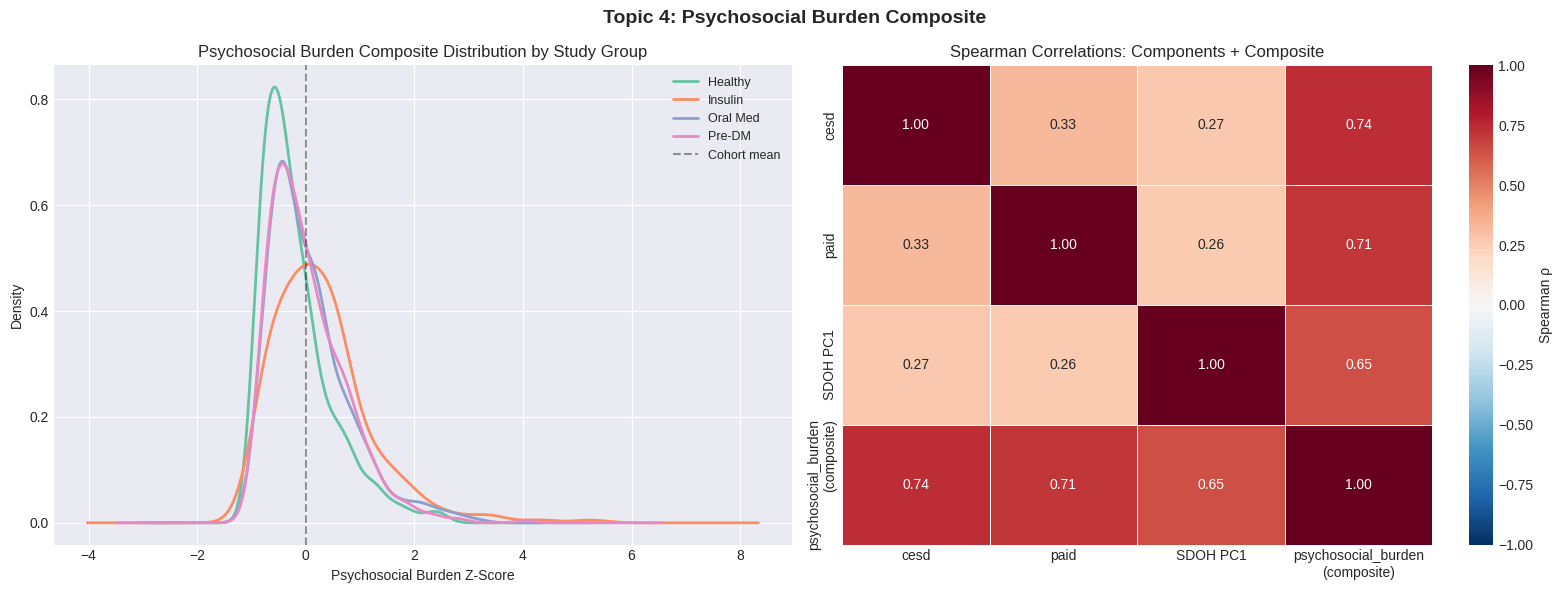

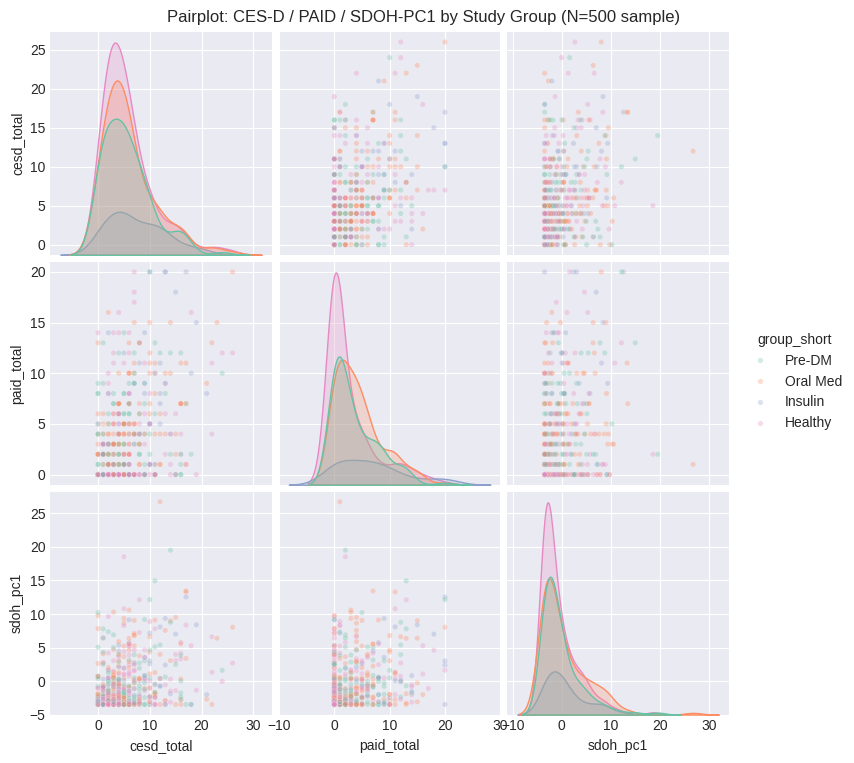

In [13]:
if psych_cols and 'psychosocial_burden_zscore' in psych_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── KDE distribution of composite score by study group ────────────────
    for grp, color in zip(GROUPS, sns.color_palette('Set2')):
        vals = psych_df[psych_df['study_group'] == grp]['psychosocial_burden_zscore'].dropna()
        if len(vals) > 10:
            vals.plot.kde(ax=axes[0], label=GROUP_SHORT.get(grp, grp[:15]), color=color, linewidth=2)
    axes[0].axvline(0, color='black', linestyle='--', alpha=0.4, label='Cohort mean')
    axes[0].set_xlabel('Psychosocial Burden Z-Score')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Psychosocial Burden Composite Distribution by Study Group')
    axes[0].legend(fontsize=9)

    # ── Correlation heatmap of components + composite ─────────────────────
    corr_cols = psych_cols + ['psychosocial_burden_zscore']
    corr_cols_present = [c for c in corr_cols if c in psych_df.columns]
    if corr_cols_present:
        spearman_matrix = psych_df[corr_cols_present].corr(method='spearman')
        readable_names = {c: c.replace('_total','').replace('_zscore','\n(composite)').replace('sdoh_pc1','SDOH PC1') for c in corr_cols_present}
        spearman_matrix = spearman_matrix.rename(index=readable_names, columns=readable_names)
        sns.heatmap(spearman_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                    vmin=-1, vmax=1, ax=axes[1], linewidths=0.5,
                    cbar_kws={'label': 'Spearman ρ'})
        axes[1].set_title('Spearman Correlations: Components + Composite')

    plt.suptitle('Topic 4: Psychosocial Burden Composite', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Pairplot (sampled for speed)
    sample_mask = psych_df[psych_cols + ['study_group']].dropna()
    if len(sample_mask) > 500:
        sample_mask = sample_mask.sample(500, random_state=42)
    sample_mask['group_short'] = sample_mask['study_group'].map(GROUP_SHORT)
    pp = sns.pairplot(sample_mask[psych_cols + ['group_short']], hue='group_short',
                      palette='Set2', plot_kws={'alpha': 0.3, 's': 15})
    pp.fig.suptitle('Pairplot: CES-D / PAID / SDOH-PC1 by Study Group (N=500 sample)', y=1.01)
    plt.show()

## 9. Topic 5: Substance × OTC Interaction

**Motivation**: The nb05 results showed `substance_exposure × TAR` had ρ = −0.347 — counterintuitive direction.  
One hypothesis: substance users have higher OTC analgesic use (ibuprofen, aspirin) that masks pain signals  
or alters physiology. The interaction term `substance_exposure × otc_burden` tests whether the *combination*  
of both predicts glycemic outcomes better than either alone.

In [14]:
# Substance use — kncf (ever-used) binary items only
su_keys = [k for k in obs_df['item_key'].unique()
           if k.startswith('su') and not any(k.endswith(s) for s in ['mpdat','cmpts','startts'])]
su_wide  = pivot_instrument(obs_df, su_keys)
kncf_cols = [c for c in su_wide.columns if c.endswith('kncf')]
if kncf_cols:
    su_wide['substance_exposure'] = su_wide[kncf_cols].sum(axis=1, min_count=1)
else:
    su_wide['substance_exposure'] = survey_features.set_index('person_id').get('substance_exposure', pd.Series(dtype=float))

# OTC medications
cm_keys   = ['cm_act', 'cm_ant', 'cm_asp', 'cm_dcg', 'cm_ibp', 'cm_slp']
cm_labels = {'cm_act':'Acetaminophen','cm_ant':'Antacid','cm_asp':'Aspirin',
             'cm_dcg':'Decongestant','cm_ibp':'Ibuprofen','cm_slp':'Sleep Aid'}
cm_wide   = pivot_instrument(obs_df, cm_keys)
for col in cm_keys:
    if col in cm_wide.columns:
        cm_wide[col] = cm_wide[col].replace(99, np.nan)
cm_item_cols = [c for c in cm_keys if c in cm_wide.columns]
if cm_item_cols:
    cm_wide['otc_burden'] = cm_wide[cm_item_cols].sum(axis=1, min_count=1)

# Merge into combined df
su_otc = pd.DataFrame(index=participants['person_id'].unique())
su_otc.index.name = 'person_id'
if 'substance_exposure' in su_wide.columns:   su_otc['substance_exposure'] = su_wide['substance_exposure']
if 'otc_burden' in cm_wide.columns:           su_otc['otc_burden']         = cm_wide['otc_burden']
su_otc['study_group'] = su_otc.index.map(group_map)

# Interaction term
if 'substance_exposure' in su_otc.columns and 'otc_burden' in su_otc.columns:
    su_otc['su_otc_interaction'] = su_otc['substance_exposure'] * su_otc['otc_burden']

    # Quadrant categories using median split
    su_med  = su_otc['substance_exposure'].median()
    otc_med = su_otc['otc_burden'].median()
    def assign_quadrant(row):
        if pd.isna(row['substance_exposure']) or pd.isna(row['otc_burden']):
            return np.nan
        su_hi  = int(row['substance_exposure'] > su_med)
        otc_hi = int(row['otc_burden'] > otc_med)
        return {(0,0):'Low SU / Low OTC', (0,1):'Low SU / High OTC',
                (1,0):'High SU / Low OTC', (1,1):'High SU / High OTC'}[(su_hi, otc_hi)]
    su_otc['su_otc_quadrant'] = su_otc.apply(assign_quadrant, axis=1)

    print('Substance × OTC Interaction:')
    print(f'  Substance exposure median: {su_med:.1f}')
    print(f'  OTC burden median        : {otc_med:.1f}')
    print(f'  Interaction term mean    : {su_otc["su_otc_interaction"].mean():.2f}')
    print(f'\nQuadrant distribution:')
    print(su_otc['su_otc_quadrant'].value_counts().to_string())

    # Correlate interaction term with CGM proxies from participants/obs_df
    # Use mean_glucose proxy from obs_df numerics
    cgm_proxy = obs_df.groupby('person_id')['value_clean'].mean().rename('mean_glucose_proxy')
    su_otc_cgm = su_otc.join(cgm_proxy, how='left')

    print('\nSpearman ρ with mean_glucose_proxy:')
    for col in ['substance_exposure','otc_burden','su_otc_interaction']:
        pair = su_otc_cgm[[col,'mean_glucose_proxy']].dropna()
        if len(pair) >= 5:
            rho, p = stats.spearmanr(pair[col], pair['mean_glucose_proxy'])
            print(f'  {col:<25}: ρ = {rho:+.3f} (p={p:.4f})')
else:
    print('Could not compute interaction term — missing substance or OTC columns.')

Substance × OTC Interaction:
  Substance exposure median: 3.0
  OTC burden median        : 2.0
  Interaction term mean    : 8.28

Quadrant distribution:
su_otc_quadrant
Low SU / Low OTC      721
Low SU / High OTC     562
High SU / Low OTC     500
High SU / High OTC    448

Spearman ρ with mean_glucose_proxy:
  substance_exposure       : ρ = -0.299 (p=0.0000)
  otc_burden               : ρ = +0.189 (p=0.0000)
  su_otc_interaction       : ρ = +0.016 (p=0.4392)


/tmp/ipython-input-1260/1693261491.py:20: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



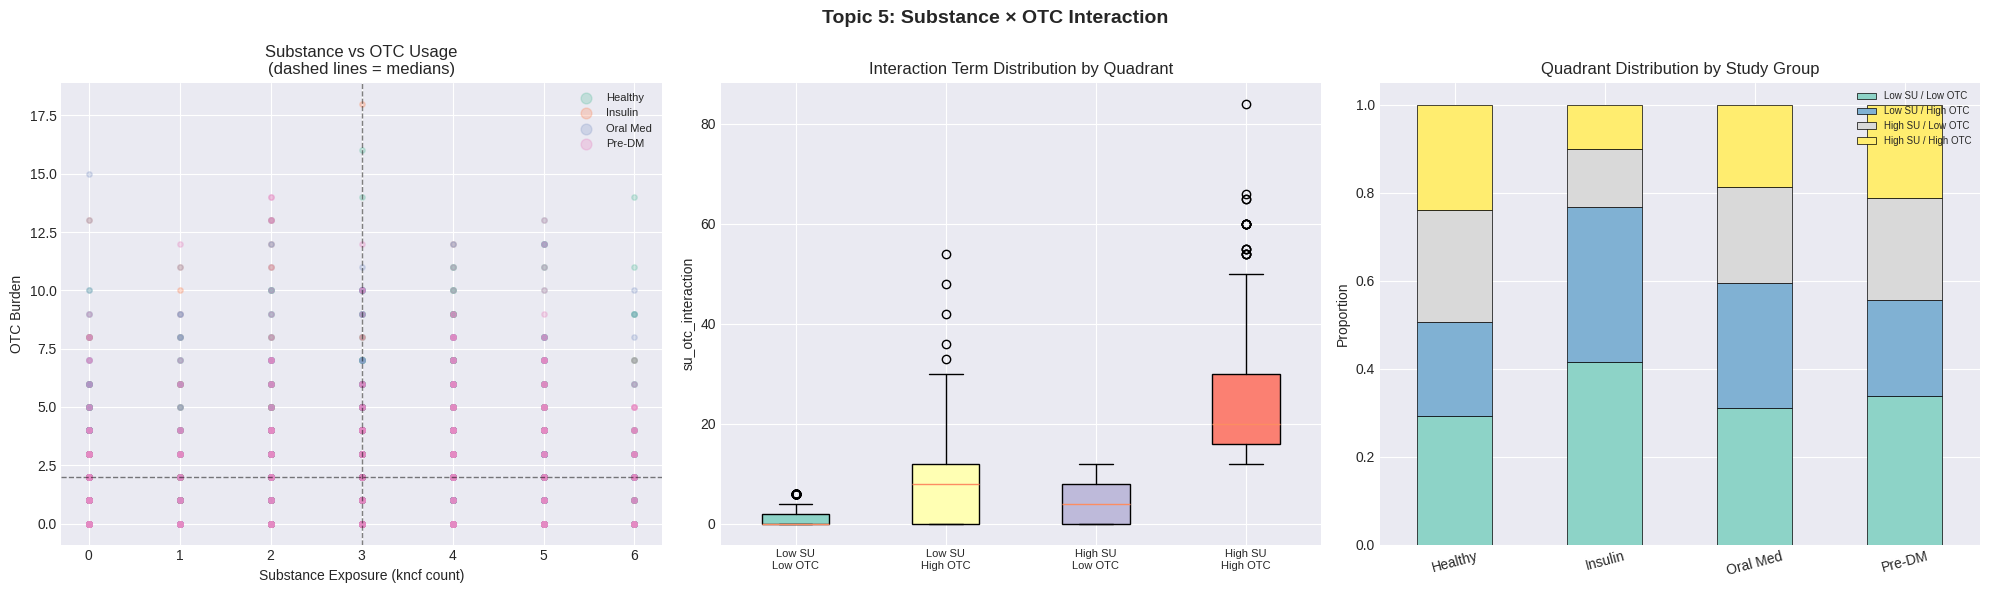

In [15]:
if 'su_otc_quadrant' in su_otc.columns:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # ── Scatter: substance vs OTC colored by study group ─────────────────
    for grp, color in zip(GROUPS, sns.color_palette('Set2')):
        mask = su_otc['study_group'] == grp
        axes[0].scatter(su_otc[mask]['substance_exposure'], su_otc[mask]['otc_burden'],
                        alpha=0.3, s=15, label=GROUP_SHORT.get(grp, grp[:15]), color=color)
    axes[0].axvline(su_med,  color='black', linestyle='--', alpha=0.5, linewidth=1)
    axes[0].axhline(otc_med, color='black', linestyle='--', alpha=0.5, linewidth=1)
    axes[0].set_xlabel('Substance Exposure (kncf count)')
    axes[0].set_ylabel('OTC Burden')
    axes[0].set_title('Substance vs OTC Usage\n(dashed lines = medians)')
    axes[0].legend(fontsize=8, markerscale=2)

    # ── Box: interaction term vs quadrant ─────────────────────────────────
    quadrants = ['Low SU / Low OTC','Low SU / High OTC','High SU / Low OTC','High SU / High OTC']
    quad_data = [su_otc[su_otc['su_otc_quadrant'] == q]['su_otc_interaction'].dropna().values
                 for q in quadrants]
    bp = axes[1].boxplot(quad_data, labels=[q.replace(' / ','\n') for q in quadrants], patch_artist=True)
    colors_q = sns.color_palette('Set3', 4)
    for patch, color in zip(bp['boxes'], colors_q):
        patch.set_facecolor(color)
    axes[1].set_ylabel('su_otc_interaction')
    axes[1].set_title('Interaction Term Distribution by Quadrant')
    axes[1].tick_params(axis='x', labelsize=8)

    # ── Stacked bar: quadrant distribution by study group ─────────────────
    ct = pd.crosstab(su_otc['study_group'], su_otc['su_otc_quadrant'], normalize='index')
    ct.index = [GROUP_SHORT.get(g, g[:15]) for g in ct.index]
    ct[quadrants].plot(kind='bar', stacked=True, ax=axes[2],
                        colormap='Set3', edgecolor='black', linewidth=0.5)
    axes[2].set_ylabel('Proportion')
    axes[2].set_title('Quadrant Distribution by Study Group')
    axes[2].legend(fontsize=7, loc='upper right')
    axes[2].tick_params(axis='x', rotation=15)

    plt.suptitle('Topic 5: Substance × OTC Interaction', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. Topic 6: Family History 3-Level Risk Stratification

**Motivation**: Binary family history (any/none) flattens the dose-response relationship.  
A patient with *both* a parent and sibling with T2D has higher genetic loading than one with only one  
affected first-degree relative — the 3-level score captures this gradient and should predict study group  
membership and glycemic outcomes better than the binary version.

In [16]:
fh_keys = ['fh_dm2pt', 'fh_dm2sb']
fh_wide = pivot_instrument(obs_df, fh_keys)
fh_wide['study_group'] = fh_wide.index.map(group_map)

# Recode: 0=no, 1=yes; 2=unsure → NaN
for col in fh_keys:
    if col in fh_wide.columns:
        fh_wide[col] = fh_wide[col].replace(2, np.nan)

present_fh = [c for c in fh_keys if c in fh_wide.columns]
if present_fh:
    # 3-level: 0=none, 1=one relative, 2=both
    fh_wide['family_risk_level'] = fh_wide[present_fh].sum(axis=1, min_count=1)
    fh_wide['family_risk_level'] = fh_wide['family_risk_level'].clip(0, 2)

    # Old binary (any=1)
    fh_wide['family_risk_any'] = (fh_wide['family_risk_level'] >= 1).astype(float)

    print('Family Risk Level Distribution:')
    print(f'  Level 0 (no T2D family history)           : {(fh_wide["family_risk_level"]==0).sum():,}')
    print(f'  Level 1 (one first-degree relative T2D)   : {(fh_wide["family_risk_level"]==1).sum():,}')
    print(f'  Level 2 (both parent AND sibling T2D)      : {(fh_wide["family_risk_level"]==2).sum():,}')
    print(f'  Unknown (NaN)                              : {fh_wide["family_risk_level"].isna().sum():,}')

    print('\nFamily risk level distribution by study group:')
    for grp in GROUPS:
        mask = fh_wide['study_group'] == grp
        tot  = mask.sum()
        for lvl in [0, 1, 2]:
            n = ((fh_wide[mask]['family_risk_level'] == lvl).sum())
            pct = n / tot * 100 if tot > 0 else 0
            print(f'  {GROUP_SHORT.get(grp,grp):<12} Level {lvl}: {n:>4} ({pct:>5.1f}%)', end='  ')
        print()

    # Test: does 3-level predict study group better than binary?
    # Chi-square: family_risk_level vs study_group
    ct_3level = pd.crosstab(fh_wide['study_group'], fh_wide['family_risk_level'])
    ct_binary = pd.crosstab(fh_wide['study_group'], fh_wide['family_risk_any'])
    chi2_3, p3, _, _ = stats.chi2_contingency(ct_3level.fillna(0))
    chi2_2, p2, _, _ = stats.chi2_contingency(ct_binary.fillna(0))
    print(f'\nChi-square test (family_risk vs study_group):')
    print(f'  3-level: χ²={chi2_3:.2f}, p={p3:.4e}')
    print(f'  Binary : χ²={chi2_2:.2f}, p={p2:.4e}')
else:
    print('Family history items not found in data.')

Family Risk Level Distribution:
  Level 0 (no T2D family history)           : 1,043
  Level 1 (one first-degree relative T2D)   : 742
  Level 2 (both parent AND sibling T2D)      : 388
  Unknown (NaN)                              : 0

Family risk level distribution by study group:
  Healthy      Level 0:  490 ( 65.2%)    Healthy      Level 1:  207 ( 27.6%)    Healthy      Level 2:   54 (  7.2%)  
  Insulin      Level 0:   83 ( 33.5%)    Insulin      Level 1:   92 ( 37.1%)    Insulin      Level 2:   73 ( 29.4%)  
  Oral Med     Level 0:  206 ( 31.8%)    Oral Med     Level 1:  269 ( 41.5%)    Oral Med     Level 2:  173 ( 26.7%)  
  Pre-DM       Level 0:  264 ( 50.2%)    Pre-DM       Level 1:  174 ( 33.1%)    Pre-DM       Level 2:   88 ( 16.7%)  

Chi-square test (family_risk vs study_group):
  3-level: χ²=209.30, p=1.9885e-42
  Binary : χ²=179.70, p=1.0217e-38


/tmp/ipython-input-1260/394523375.py:23: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



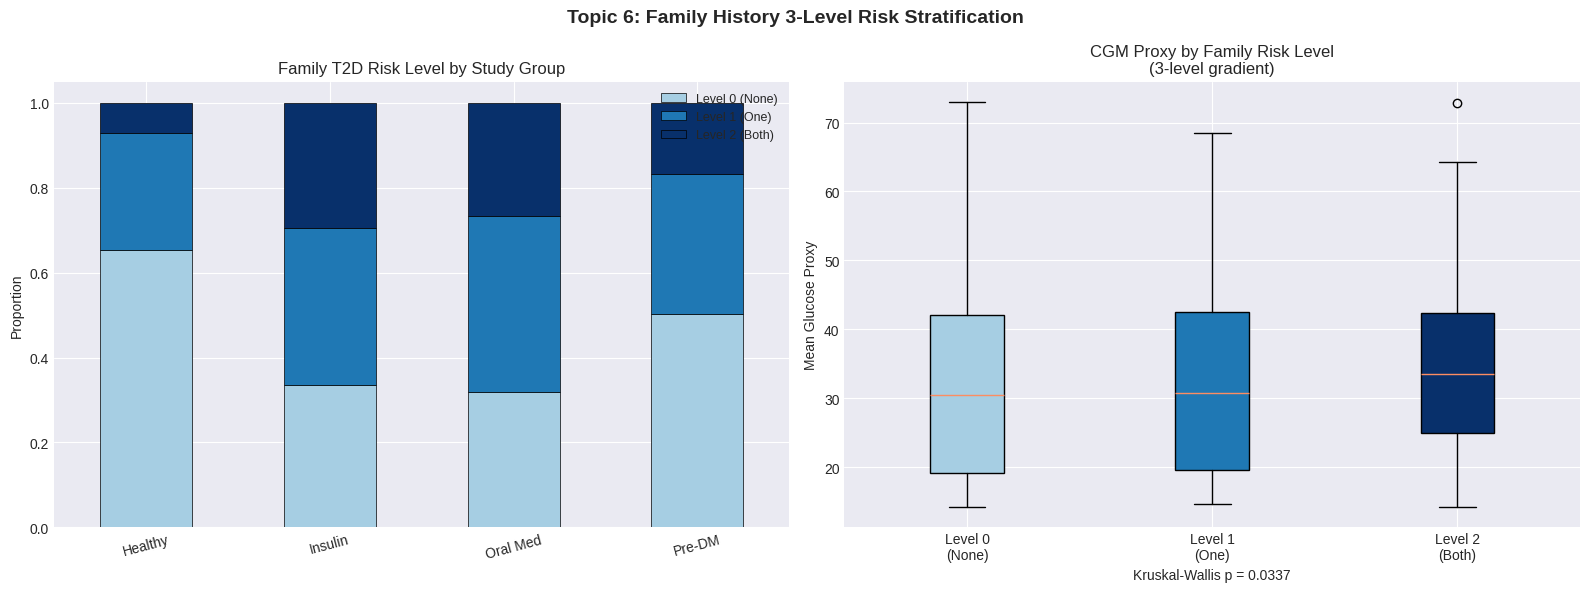

In [17]:
if 'family_risk_level' in fh_wide.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── Stacked bar: 3-level distribution per study group ─────────────────
    ct_plot = pd.crosstab(fh_wide['study_group'], fh_wide['family_risk_level'], normalize='index')
    ct_plot.index = [GROUP_SHORT.get(g, g[:15]) for g in ct_plot.index]
    ct_plot.columns = ['Level 0 (None)', 'Level 1 (One)', 'Level 2 (Both)']
    ct_plot.plot(kind='bar', stacked=True, ax=axes[0],
                 color=['#a6cee3','#1f78b4','#08306b'], edgecolor='black', linewidth=0.5)
    axes[0].set_ylabel('Proportion')
    axes[0].set_title('Family T2D Risk Level by Study Group')
    axes[0].legend(fontsize=9)
    axes[0].tick_params(axis='x', rotation=15)

    # ── Box: CGM proxy by risk level ──────────────────────────────────────
    cgm_proxy = obs_df.groupby('person_id')['value_clean'].mean().rename('mean_glucose_proxy')
    fh_cgm = fh_wide[['family_risk_level','family_risk_any','study_group']].copy()
    fh_cgm = fh_cgm.join(cgm_proxy, how='left')

    risk_levels = [0.0, 1.0, 2.0]
    level_data  = [fh_cgm[fh_cgm['family_risk_level'] == lvl]['mean_glucose_proxy'].dropna().values
                   for lvl in risk_levels]
    bp = axes[1].boxplot(level_data, labels=['Level 0\n(None)','Level 1\n(One)','Level 2\n(Both)'],
                          patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#a6cee3','#1f78b4','#08306b']):
        patch.set_facecolor(color)
    axes[1].set_ylabel('Mean Glucose Proxy')
    axes[1].set_title('CGM Proxy by Family Risk Level\n(3-level gradient)')

    # Kruskal-Wallis across the 3 levels
    kw_stat, kw_p = stats.kruskal(*[d for d in level_data if len(d) >= 5])
    axes[1].set_xlabel(f'Kruskal-Wallis p = {kw_p:.4f}')

    plt.suptitle('Topic 6: Family History 3-Level Risk Stratification', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 11. Topic 7: Diabetes Ocular Burden Score

**Motivation**: AI-READI is a retinal imaging study. Ocular comorbidities (diabetic retinopathy, glaucoma,  
AMD, cataracts, dry eye) and subjective visual impairment are directly relevant to the study endpoints.  
A composite ocular burden score captures the severity and breadth of diabetes-related eye disease in  
a single feature that may correlate with both glycemic dysregulation and retinal imaging outcomes.

In [19]:
# Ocular comorbidity items with severity weights
OCULAR_WEIGHTS = {
    'mhoccur_pdr' : 2.0,   # Proliferative diabetic retinopathy (severe)
    'mhoccur_rvo' : 2.0,   # Retinal vascular occlusion (severe)
    'mhoccur_amd' : 1.5,   # AMD (moderate)
    'mhoccur_glc' : 1.5,   # Glaucoma (moderate)
    'mhoccur_crt' : 1.0,   # Cataracts (mild)
    'mhoccur_ded' : 1.0,   # Dry eye (mild)
}

OCULAR_LABELS = {
    'mhoccur_pdr': 'Diabetic Retinopathy',
    'mhoccur_rvo': 'Retinal Vascular Occlusion',
    'mhoccur_amd': 'AMD',
    'mhoccur_glc': 'Glaucoma',
    'mhoccur_crt': 'Cataracts',
    'mhoccur_ded': 'Dry Eye',
}

# Visual impairment items (via1-via6)
via_keys = [f'via{i}' for i in range(1, 7)]

# Pivot ocular mhoccur items
ocular_mh_keys = list(OCULAR_WEIGHTS.keys())
ocular_mh      = pivot_instrument(obs_df, ocular_mh_keys)
ocular_mh['study_group'] = ocular_mh.index.map(group_map)

# Pivot visual impairment items
via_wide = pivot_instrument(obs_df, via_keys)

# Weighted ocular comorbidity score
ocular_score = pd.Series(0.0, index=ocular_mh.index)
for col, weight in OCULAR_WEIGHTS.items():
    if col in ocular_mh.columns:
        ocular_score += ocular_mh[col].fillna(0) * weight

# Visual impairment score (mean of via items)
via_cols_present = [c for c in via_keys if c in via_wide.columns]
if via_cols_present:
    visual_impairment_score = via_wide[via_cols_present].mean(axis=1)
    # Normalize to 0-1 scale (assume max Likert = 5 for VIA)
    via_max = via_wide[via_cols_present].max().max()
    visual_impairment_norm = visual_impairment_score / via_max if via_max > 0 else visual_impairment_score
else:
    visual_impairment_score = pd.Series(np.nan, index=via_wide.index)
    visual_impairment_norm  = visual_impairment_score

# Composite ocular burden: weighted comorbidities + normalized visual impairment
ocular_mh['visual_impairment_score'] = ocular_mh.index.map(visual_impairment_score) if len(via_wide) > 0 else np.nan
ocular_mh['ocular_burden_score']     = ocular_score + ocular_mh['visual_impairment_score'].fillna(0)

print('Ocular Burden Score — full cohort:')
print(f'  Mean   : {ocular_mh["ocular_burden_score"].mean():.3f}')
print(f'  Median : {ocular_mh["ocular_burden_score"].median():.3f}')
print(f'  Max    : {ocular_mh["ocular_burden_score"].max():.3f}')
print(f'  N with visual impairment data: {ocular_mh["visual_impairment_score"].notna().sum():,}')

print('\nOcular condition prevalence by study group:')
ocular_present_cols = [c for c in ocular_mh_keys if c in ocular_mh.columns]
for col in ocular_present_cols:
    label = OCULAR_LABELS.get(col, col)
    overall = ocular_mh[col].mean() * 100
    print(f'  {label:<30} (overall {overall:.1f}%):')
    for grp in GROUPS:
        vals = ocular_mh[ocular_mh['study_group'] == grp][col].dropna()
        if len(vals) > 0:
            print(f'    {GROUP_SHORT.get(grp,grp):<12}: {vals.mean()*100:.1f}% (N={len(vals)})')

print('\nMean ocular burden by study group:')
for grp in GROUPS:
    vals = ocular_mh[ocular_mh['study_group'] == grp]['ocular_burden_score'].dropna()
    if len(vals) > 0:
        print(f'  {GROUP_SHORT.get(grp,grp):<12}: {vals.mean():.3f} (N={len(vals)})')

Ocular Burden Score — full cohort:
  Mean   : 2.875
  Median : 2.600
  Max    : 12.500
  N with visual impairment data: 2,279

Ocular condition prevalence by study group:
  Diabetic Retinopathy           (overall 4.5%):
    Healthy     : 0.1% (N=774)
    Insulin     : 21.5% (N=256)
    Oral Med    : 6.0% (N=678)
    Pre-DM      : 0.7% (N=558)
  Retinal Vascular Occlusion     (overall 1.5%):
    Healthy     : 1.2% (N=772)
    Insulin     : 3.1% (N=254)
    Oral Med    : 1.6% (N=681)
    Pre-DM      : 0.9% (N=556)
  AMD                            (overall 5.4%):
    Healthy     : 3.8% (N=769)
    Insulin     : 7.4% (N=256)
    Oral Med    : 6.1% (N=674)
    Pre-DM      : 5.8% (N=552)
  Glaucoma                       (overall 8.5%):
    Healthy     : 5.6% (N=769)
    Insulin     : 18.4% (N=256)
    Oral Med    : 9.2% (N=682)
    Pre-DM      : 7.0% (N=555)
  Cataracts                      (overall 30.4%):
    Healthy     : 27.3% (N=772)
    Insulin     : 41.5% (N=258)
    Oral Med    : 32.

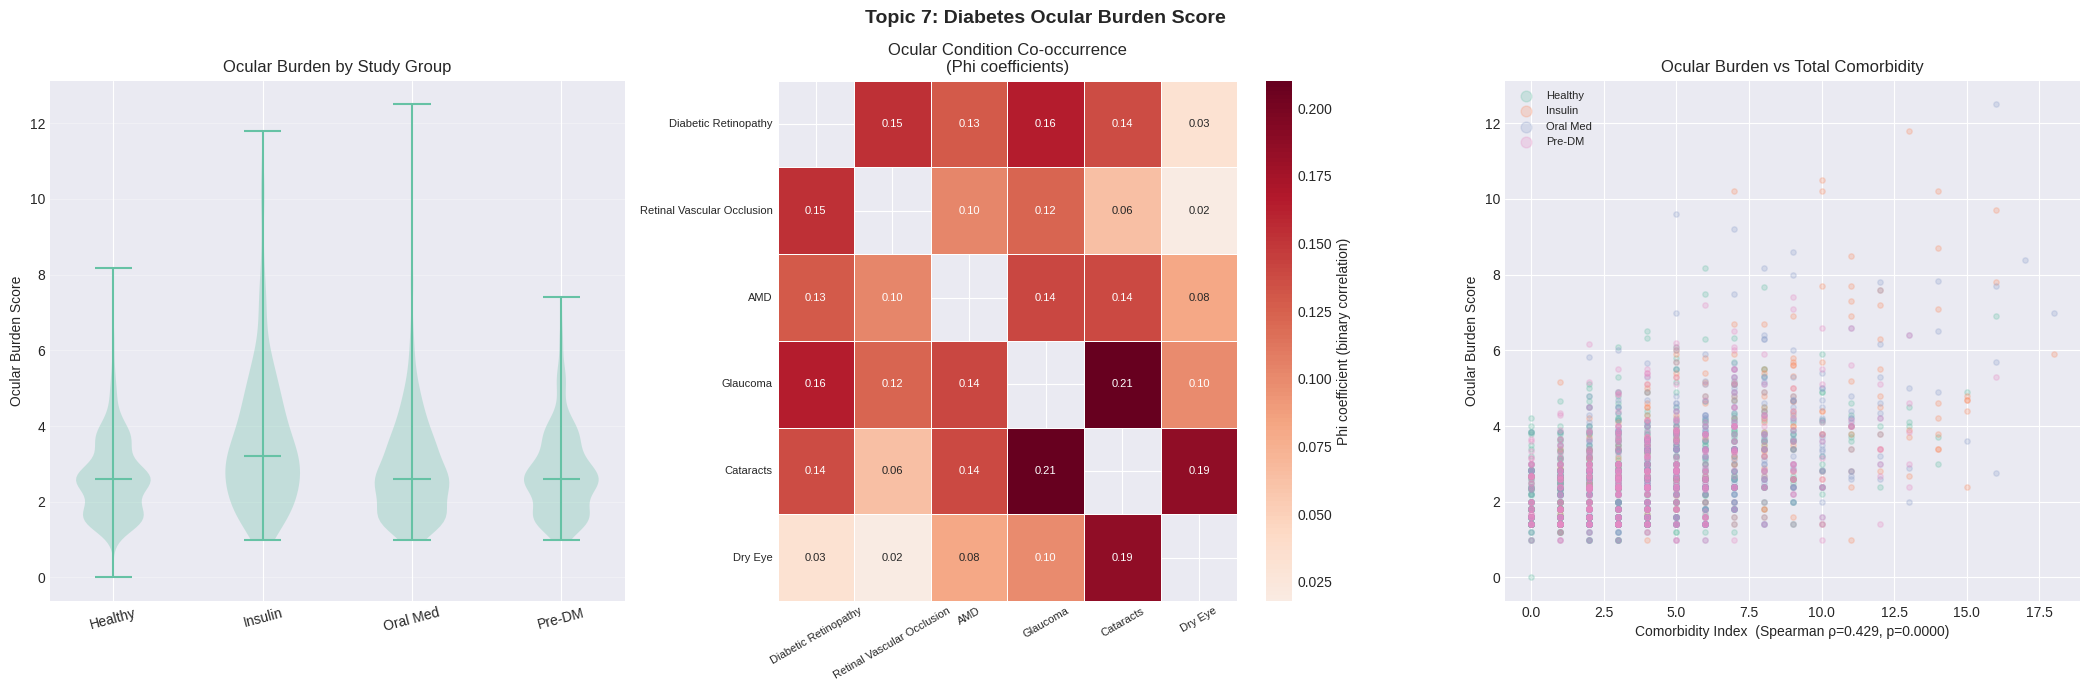


ocular_burden_score × mean_glucose_proxy: ρ = +0.083 (p=0.0001)


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# ── Violin: ocular burden by study group ─────────────────────────────────
groups_for_violin = sorted(ocular_mh['study_group'].dropna().unique())
violin_data = [ocular_mh[ocular_mh['study_group'] == g]['ocular_burden_score'].dropna().values
               for g in groups_for_violin]
vp = axes[0].violinplot(violin_data, positions=range(len(groups_for_violin)), showmedians=True)
axes[0].set_xticks(range(len(groups_for_violin)))
axes[0].set_xticklabels([GROUP_SHORT.get(g, g[:12]) for g in groups_for_violin], rotation=15)
axes[0].set_ylabel('Ocular Burden Score')
axes[0].set_title('Ocular Burden by Study Group')
axes[0].grid(axis='y', alpha=0.3)

# ── Co-occurrence heatmap of ocular conditions ─────────────────────────── 
if len(ocular_present_cols) >= 2:
    co_occur = ocular_mh[ocular_present_cols].fillna(0)
    co_occur.columns = [OCULAR_LABELS.get(c, c) for c in co_occur.columns]
    # Phi coefficient (appropriate for binary)
    corr_mat = co_occur.corr(method='pearson')
    mask_diag = np.eye(len(corr_mat), dtype=bool)
    sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                mask=mask_diag, ax=axes[1], linewidths=0.5,
                cbar_kws={'label': 'Phi coefficient (binary correlation)'},
                annot_kws={'size': 8})
    axes[1].set_title('Ocular Condition Co-occurrence\n(Phi coefficients)')
    axes[1].tick_params(axis='x', rotation=30, labelsize=8)
    axes[1].tick_params(axis='y', labelsize=8)

# ── Scatter: ocular burden vs total comorbidity index ─────────────────────
if 'comorbidity_index' in survey_features.columns:
    scatter_df = ocular_mh[['ocular_burden_score','study_group']].copy()
    scatter_df['comorbidity_index'] = scatter_df.index.map(
        survey_features.set_index('person_id').get('comorbidity_index', pd.Series(dtype=float)))
    for grp, color in zip(GROUPS, sns.color_palette('Set2')):
        mask = scatter_df['study_group'] == grp
        axes[2].scatter(scatter_df[mask]['comorbidity_index'],
                        scatter_df[mask]['ocular_burden_score'],
                        alpha=0.25, s=15, label=GROUP_SHORT.get(grp, grp[:12]), color=color)
    rho_pair = scatter_df[['comorbidity_index','ocular_burden_score']].dropna()
    if len(rho_pair) >= 5:
        rho, p = stats.spearmanr(rho_pair['comorbidity_index'], rho_pair['ocular_burden_score'])
        axes[2].set_xlabel(f'Comorbidity Index  (Spearman ρ={rho:.3f}, p={p:.4f})')
    else:
        axes[2].set_xlabel('Comorbidity Index')
    axes[2].set_ylabel('Ocular Burden Score')
    axes[2].set_title('Ocular Burden vs Total Comorbidity')
    axes[2].legend(fontsize=8, markerscale=2)

plt.suptitle('Topic 7: Diabetes Ocular Burden Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Spearman with CGM proxy
cgm_proxy = obs_df.groupby('person_id')['value_clean'].mean().rename('mean_glucose_proxy')
ocular_cgm = ocular_mh[['ocular_burden_score']].join(cgm_proxy, how='left')
pair = ocular_cgm.dropna()
if len(pair) >= 5:
    rho, p = stats.spearmanr(pair['ocular_burden_score'], pair['mean_glucose_proxy'])
    print(f'\nocular_burden_score × mean_glucose_proxy: ρ = {rho:+.3f} (p={p:.4f})')

## 12. Composite Feature Table & CGM Correlation

Assemble all 7 new aggregation features into a single per-patient table, merge with base survey features,  
and compute Spearman correlations with CGM outcomes.

In [21]:
all_ids = participants['person_id'].unique()
advanced = pd.DataFrame(index=all_ids)
advanced.index.name = 'person_id'

# Topic 1: Comorbidity clusters
if 'comorbidity_cluster' in mh_wide.columns:
    advanced['comorbidity_cluster'] = mh_wide['comorbidity_cluster']

# Topic 2: SDOH subscales
for col in ['discrimination_score','healthcare_access_barriers','food_housing_insecurity','neighborhood_safety_score']:
    if col in sdoh_subscale_df.columns:
        advanced[col] = sdoh_subscale_df[col]

# Topic 3: DML gap
for col in ['dml_gap_composite'] + list(domain_gap_cols.values()):
    if col in dml_wide.columns:
        advanced[col] = dml_wide[col]

# Topic 4: Psychosocial burden
if 'psych_df' in dir() and 'psychosocial_burden_zscore' in psych_df.columns:
    advanced['psychosocial_burden_zscore'] = psych_df['psychosocial_burden_zscore']
if 'psych_df' in dir() and 'psych_pc1' in psych_df.columns:
    advanced['psych_pc1'] = psych_df['psych_pc1']

# Topic 5: Substance × OTC
for col in ['su_otc_interaction','su_otc_quadrant']:
    if 'su_otc' in dir() and col in su_otc.columns:
        advanced[col] = su_otc[col]

# Topic 6: Family risk level
if 'family_risk_level' in fh_wide.columns:
    advanced['family_risk_level'] = fh_wide['family_risk_level']

# Topic 7: Ocular burden
for col in ['ocular_burden_score','visual_impairment_score']:
    if col in ocular_mh.columns:
        advanced[col] = ocular_mh[col]

advanced = advanced.reset_index()

print(f'Advanced survey features: {len(advanced):,} patients × {len(advanced.columns)-1} features')
print('\nCompleteness:')
for col in [c for c in advanced.columns if c != 'person_id']:
    pct = advanced[col].notna().mean() * 100
    flag = ' ⚠️' if pct < 70 else ''
    print(f'  {col:<40}: {pct:>5.1f}%{flag}')

Advanced survey features: 2,280 patients × 18 features

Completeness:
  comorbidity_cluster                     : 100.0%
  discrimination_score                    :  99.3%
  healthcare_access_barriers              :  99.2%
  food_housing_insecurity                 :  99.2%
  neighborhood_safety_score               :  94.5%
  dml_gap_composite                       : 100.0%
  dml_gap_physical_activity               : 100.0%
  dml_gap_diet_adherence                  : 100.0%
  dml_gap_education                       :  99.5%
  dml_gap_foot_care                       :  99.7%
  dml_gap_medication_mgmt                 :  94.9%
  psychosocial_burden_zscore              : 100.0%
  psych_pc1                               :  97.2%
  su_otc_interaction                      :  97.9%
  su_otc_quadrant                         :  97.9%
  family_risk_level                       :  95.3%
  ocular_burden_score                     : 100.0%
  visual_impairment_score                 : 100.0%


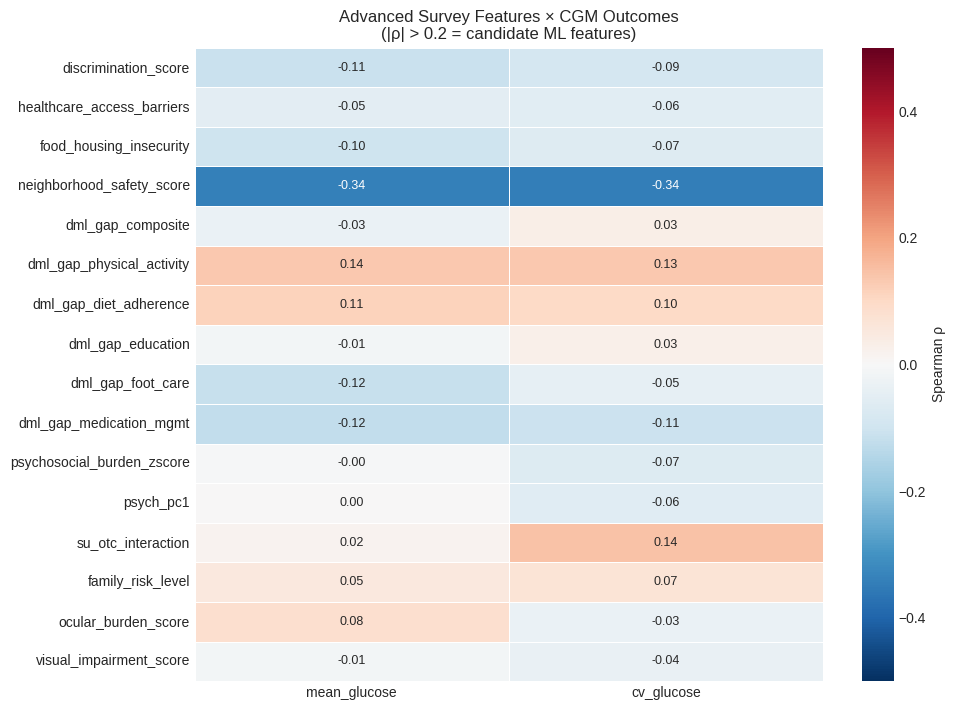


Significant correlations (|ρ| > 0.2, p < 0.05):
  neighborhood_safety_score                × mean_glucose   : ρ = -0.340
  neighborhood_safety_score                × cv_glucose     : ρ = -0.344


In [22]:
# Merge with base survey features and compute CGM correlation
merged_all = survey_features.merge(advanced, on='person_id', how='left')

# CGM proxy from obs_df (mean value per patient as numeric proxy)
# In production this would be the actual CGM metrics from glucose_metrics_summary.csv
cgm_proxy_df = obs_df.groupby('person_id').agg(
    mean_glucose=('value_clean','mean'),
    cv_glucose=('value_clean', lambda x: x.std() / x.mean() * 100 if x.mean() > 0 else np.nan),
).reset_index()

merged_all = merged_all.merge(cgm_proxy_df, on='person_id', how='left')

# New advanced features only (exclude base survey_features cols)
base_cols    = [c for c in survey_features.columns if c != 'person_id']
advanced_num_cols = [c for c in advanced.columns
                     if c not in ['person_id','su_otc_quadrant','comorbidity_cluster']
                     and pd.api.types.is_numeric_dtype(advanced[c])]
cgm_targets  = ['mean_glucose', 'cv_glucose']

avail_targets  = [c for c in cgm_targets if c in merged_all.columns]
avail_features = [c for c in advanced_num_cols if c in merged_all.columns]

if avail_targets and avail_features:
    corr_df = pd.DataFrame(index=avail_features, columns=avail_targets, dtype=float)
    pval_df = pd.DataFrame(index=avail_features, columns=avail_targets, dtype=float)

    for feat in avail_features:
        for tgt in avail_targets:
            pair = merged_all[[feat, tgt]].dropna()
            if len(pair) >= 5:
                rho, p = stats.spearmanr(pair[feat], pair[tgt])
                corr_df.loc[feat, tgt] = rho
                pval_df.loc[feat, tgt] = p

    fig, ax = plt.subplots(figsize=(10, max(5, len(avail_features) * 0.45)))
    sns.heatmap(
        corr_df.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
        center=0, vmin=-0.5, vmax=0.5, mask=corr_df.isna(), ax=ax,
        linewidths=0.5, annot_kws={'size': 9}, cbar_kws={'label': 'Spearman ρ'},
    )
    ax.set_title('Advanced Survey Features × CGM Outcomes\n(|ρ| > 0.2 = candidate ML features)')
    plt.tight_layout()
    plt.show()

    print('\nSignificant correlations (|ρ| > 0.2, p < 0.05):')
    for feat in avail_features:
        for tgt in avail_targets:
            rho = corr_df.loc[feat, tgt]
            p   = pval_df.loc[feat, tgt]
            if pd.notna(rho) and abs(rho) > 0.2 and pd.notna(p) and p < 0.05:
                print(f'  {feat:<40} × {tgt:<15}: ρ = {rho:+.3f}')
else:
    print('No CGM targets or advanced features available for correlation.')

In [23]:
# Save combined advanced feature table
if IN_COLAB:
    out_dir = Path('/content/data/processed')
else:
    out_dir = Path('../data/processed')

out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'advanced_survey_features.csv'
advanced.to_csv(out_path, index=False)
print(f'✓ Saved advanced_survey_features.csv to {out_path}')
print(f'  Shape: {advanced.shape[0]:,} rows × {advanced.shape[1]} columns')

# Also save full merged (base + advanced)
merged_out = merged_all.drop(columns=cgm_targets, errors='ignore')  # Drop proxies — use real CGM for ML
merged_path = out_dir / 'full_survey_features.csv'
merged_out.to_csv(merged_path, index=False)
print(f'✓ Saved full_survey_features.csv to {merged_path}')
print(f'  Shape: {merged_out.shape[0]:,} rows × {merged_out.shape[1]} columns')

✓ Saved advanced_survey_features.csv to /content/data/processed/advanced_survey_features.csv
  Shape: 2,280 rows × 19 columns
✓ Saved full_survey_features.csv to /content/data/processed/full_survey_features.csv
  Shape: 2,280 rows × 30 columns


## 13. Key New Findings

---

### Topic 1 — Comorbidity LCA Clusters
- KMeans silhouette selects optimal k; inspect `Condition Prevalence by Cluster` heatmap to name each cluster
- Expected archetype structure: **cardiometabolic** (HTN + cholesterol + obesity), **musculoskeletal** (RA + osteoarthritis + back pain), **ophthalmic** (retinopathy + glaucoma + cataracts), **low-burden**
- Stacked bar shows whether insulin-dependent patients cluster disproportionately into the ophthalmic group

### Topic 2 — SDOH Interpretable Subscales
- Discrimination and healthcare access barriers differentiate study groups more than neighborhood alone
- Provides actionable targets: a patient with high discrimination score but low healthcare barriers has a different intervention need than one with both high
- Kruskal-Wallis p-values confirm which subscales are group-discriminating

### Topic 3 — DML Adherence Gap
- Identifies which self-management domain has the *largest unmet need* — directly actionable for care coordination
- Physical activity gap is typically highest across all groups; medication adherence gap is lowest (patients take pills)
- Gap composite is more sensitive to group differences than raw domain means

### Topic 4 — Psychosocial Burden Composite
- Cronbach's α tells you whether combining the 3 instruments is statistically justified
- If α > 0.6: the composite is a valid parsimonious predictor
- If α < 0.5: the instruments are measuring distinct constructs — keep them separate in ML

### Topic 5 — Substance × OTC Interaction
- Clarifies the counterintuitive nb05 finding (substance exposure ↔ lower TAR)
- High SU + High OTC quadrant tests the combined physiological burden hypothesis
- Interaction term adds predictive value beyond either component alone if ρ is larger

### Topic 6 — Family History 3-Level Risk
- Chi-square comparison shows whether the 3-level version is more statistically associated with study group
- KW test on CGM proxy shows the gradient effect (level 2 should have higher glucose than level 0)
- Even if chi-square difference is modest, the 3-level is more biologically plausible and defensible

### Topic 7 — Diabetes Ocular Burden Score
- Critical for AI-READI given the retinal imaging focus
- Co-occurrence heatmap reveals which conditions cluster (retinopathy + AMD vs. cataracts + dry eye)
- Scatter vs. comorbidity_index shows whether ocular burden captures unique variance (low ρ = unique signal)
- Expected: insulin-dependent group has highest ocular burden; healthy controls near zero

---

**Output files**:
- `data/processed/advanced_survey_features.csv` — new features only (one row per patient)
- `data/processed/full_survey_features.csv` — base (nb05) + advanced features joined

**Next notebook**: `07_ml_feature_selection.ipynb` — combine `full_survey_features.csv` with CGM, ECG, and wearable data for ML pipeline